In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob 
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator,MonthLocator,DayLocator
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
# from mpl_toolkits.basemap import Basemap
# import cmocean as cm

month_fmt = DateFormatter('%b')
def m_fmt(tim, pos=None):
    return month_fmt(tim)[0]
# import xrft as xt

import matplotlib.pyplot as plt
import numpy as np

import pyart
import matplotlib
import cmweather
import xarray as xr
import numpy as np
from colorspacious import cspace_convert

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cmocean
from matplotlib import colors

In [20]:
# Model temperature and salinity data
temp=xr.open_dataset('BoB_Temp_Sur_80_14.nc') # TEMP1 variable
temp = temp.drop_vars(['LAT_RHO379_689_bnds', 'DEPTH1_1_bnds'])
TEMP=temp.squeeze()
mod = TEMP.sel(
    LON_RHO577_841=slice(78,100),
    LAT_RHO379_689=slice(4,25),
    TIME=slice('1980-01-15','2014-10-17') 
)
temp_clim = mod.groupby('TIME.month').mean('TIME')
# print(temp_clim)

ds1=xr.open_dataset('BoB_Salt_Sur_80_14.nc') # TEMP1 variable
ds1 = ds1.drop_vars(['LAT_RHO379_689_bnds', 'DEPTH1_1_bnds'])
ds1=ds1.squeeze()
mod = ds1.sel(
    LON_RHO577_841=slice(78,100),
    LAT_RHO379_689=slice(4,25),
    TIME=slice('1980-01-15','2014-10-17') 
)
salt_clim = mod.groupby('TIME.month').mean('TIME')
# print(salt_clim)
temp_clim=temp_clim.mean(dim='month')
salt_clim=salt_clim.mean(dim='month')
# temp_clim,salt_clim

In [21]:
ds1=xr.open_dataset('BoB_Salt_Sur_80_14.nc') # TEMP1 variable
ds1 = ds1.drop_vars(['LAT_RHO379_689_bnds', 'DEPTH1_1_bnds'])
ds1=ds1.squeeze()
mod = ds1.sel(
    LON_RHO577_841=slice(78,100),
    LAT_RHO379_689=slice(4,25),
    TIME=slice('1980-01-15','2014-10-17') 
)
model_clim = mod.groupby('TIME.month').mean('TIME')
print(model_clim)

## WOA salinity data
ds2=xr.open_dataset('Salinity.nc') # SMN variable
ds2 = ds2.drop_vars(['TIME_bnds', 'LEV_bnds'])
ds2=ds2.isel(LEV=0)
ds2=ds2.squeeze()
# print(ds2)
obs1 = ds2.sel( 
    LON211_300=slice(78,100),
    LAT61_120=slice(4,25),
)
print(obs1)

<xarray.Dataset> Size: 7MB
Dimensions:         (month: 12, LAT_RHO379_689: 262, LON_RHO577_841: 265)
Coordinates:
  * LON_RHO577_841  (LON_RHO577_841) float32 1kB 78.0 78.08 ... 99.92 100.0
  * LAT_RHO379_689  (LAT_RHO379_689) float32 1kB 4.018 4.101 ... 24.87 24.95
    DEPTH1_1        float32 4B -0.0
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    SALT            (month, LAT_RHO379_689, LON_RHO577_841) float64 7MB 34.7 ...
Attributes:
    history:      FERRET V7.3 (optimized) 17-Apr-25
    Conventions:  CF-1.6
<xarray.Dataset> Size: 23kB
Dimensions:     (LON211_300: 22, LAT61_120: 21, TIME: 12)
Coordinates:
  * LON211_300  (LON211_300) float64 176B 78.5 79.5 80.5 81.5 ... 97.5 98.5 99.5
  * LAT61_120   (LAT61_120) float64 168B 4.5 5.5 6.5 7.5 ... 21.5 22.5 23.5 24.5
    LEV         float64 8B 0.0
  * TIME        (TIME) object 96B -001-01-15 00:00:00 ... -001-12-15 00:00:00
Data variables:
    SMN         (TIME, LAT61_120, LON211_300) float32 22kB .

In [22]:
# # model have low resolution that obserrvations so, observations need to regrid
mod_clim_regd = []
mod_clim_regd = model_clim.interp(
    LON_RHO577_841=obs1.LON211_300,
    LAT_RHO379_689=obs1.LAT61_120,
    method='nearest'
)
# print(mod_clim_regd)
mod_clim_regd.dims

if 'TIME' in obs1.dims or 'TIME' in obs1.coords:
    obs1 = obs1.rename({'TIME': 'month'})
obs1 = obs1.assign_coords(month=mod_clim_regd['month'])
print(obs1)
obs_var = obs1['SMN'] ## 'tos' : temperature 'sos' : salinity
mod_var = mod_clim_regd['SALT']
obs_var, mod_var
bias_salt = (mod_var - obs_var).mean(dim='month')
bias_salt.mean()

<xarray.Dataset> Size: 23kB
Dimensions:     (LON211_300: 22, LAT61_120: 21, month: 12)
Coordinates:
  * LON211_300  (LON211_300) float64 176B 78.5 79.5 80.5 81.5 ... 97.5 98.5 99.5
  * LAT61_120   (LAT61_120) float64 168B 4.5 5.5 6.5 7.5 ... 21.5 22.5 23.5 24.5
    LEV         float64 8B 0.0
    DEPTH1_1    float32 4B -0.0
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    SMN         (month, LAT61_120, LON211_300) float32 22kB ...
Attributes:
    history:      FERRET V6.5   5-Nov-24
    Conventions:  CF-1.0


<xarray.DataArray ()> Size: 8B
array(0.3475171)
Coordinates:
    DEPTH1_1  float32 4B -0.0
    LEV       float64 8B 0.0

In [23]:
obser=obs1.mean(dim=['LON211_300','LAT61_120'])
mod=mod_clim_regd.mean(dim=['LON211_300','LAT61_120'])

In [24]:
import xskillscore as xs
corr_s = xs.pearson_r(mod['SALT'], obser['SMN'], dim='month')  # check varaible names in file, for Glory : salinity
rmse_s = xs.rmse(mod['SALT'], obser['SMN'], dim='month')  # CMEMS : sos varaible
pval_s = xs.pearson_r_p_value(mod['SALT'], obser['SMN'], dim='month')
print(bias_salt.mean()),print(rmse_s.mean()), print(corr_s.mean()), print(pval_s.mean())

<xarray.DataArray ()> Size: 8B
array(0.3475171)
Coordinates:
    DEPTH1_1  float32 4B -0.0
    LEV       float64 8B 0.0
<xarray.DataArray ()> Size: 8B
array(0.31349828)
Coordinates:
    DEPTH1_1  float32 4B -0.0
    LEV       float64 8B 0.0
<xarray.DataArray ()> Size: 8B
array(0.56112677)
Coordinates:
    DEPTH1_1  float32 4B -0.0
    LEV       float64 8B 0.0
<xarray.DataArray ()> Size: 8B
array(0.05767005)
Coordinates:
    DEPTH1_1  float32 4B -0.0
    LEV       float64 8B 0.0


(None, None, None, None)

In [25]:
# Model temeprature data
import xarray as xr
import numpy as np
temp=xr.open_dataset('BoB_Temp_Sur_80_14.nc') # TEMP1 variable
temp = temp.drop_vars(['LAT_RHO379_689_bnds', 'DEPTH1_1_bnds'])
TEMP=temp.squeeze()
mod = TEMP.sel(
    LON_RHO577_841=slice(78,100),
    LAT_RHO379_689=slice(4,25),
    TIME=slice('1980-01-15','2014-10-17') 
)
model_clim = mod.groupby('TIME.month').mean('TIME')

# WOA temeprature data
ds2=xr.open_dataset('Temp.nc') # SMN variable
ds2=ds2.isel(LEV=0)
ds2=ds2.squeeze()
obs1 = ds2.sel( 
    LON211_300=slice(78,100),
    LAT61_120=slice(4,25),
#     TIME=slice('1980-01-16','2014-10-16') 
)
obs2 = obs1.groupby('TIME.month').mean('TIME')
obs1=obs2
# print(obs1)

In [26]:
# # # model have low resolution that obserrvations so, observations need to regrid
mod_clim_regd = []
mod_clim_regd = model_clim.interp(
    LON_RHO577_841=obs1.LON211_300,
    LAT_RHO379_689=obs1.LAT61_120,
    method='nearest'
)
# print(mod_clim_regd),print(obs1)
mod_clim_regd.dims
obs_var = obs1['TMN']
mod_var = mod_clim_regd['TEMP']
bias_temp = (mod_var - obs_var).mean(dim='month')

obser=obs1.mean(dim=['LON211_300','LAT61_120'])
mod=mod_clim_regd.mean(dim=['LON211_300','LAT61_120'])
import xskillscore as xs
corr_t = xs.pearson_r(mod['TEMP'], obser['TMN'], dim='month')  # check varaible names in file, for Glory : salinity
rmse_t = xs.rmse(mod['TEMP'], obser['TMN'], dim='month')  # CMEMS : sos varaible
pval_t = xs.pearson_r_p_value(mod['TEMP'], obser['TMN'], dim='month')
# print(bias_temp.mean()),print(rmse_t), print(corr_t), print(pval_t)

In [27]:
def plot_map(ax, map, data, lon, lat, cmap, levels=None, extend='neither', map_style=None, show_lat=True, show_lon=True):

    if map_style == 'contour':
        cf = map.contourf(lon, lat, data,
                          levels=levels,
                          cmap=cmap,
                          extend=extend,
                          ax=ax)

    elif map_style == 'pc':
        cf = map.pcolormesh(lon, lat, data,
                            cmap=cmap,
                            shading='gouraud',
                            edgecolors='face',
                            ax=ax)

    else:
        print('Not possible')

    map.fillcontinents(color='grey', lake_color='grey', ax=ax)
    map.drawcoastlines(ax=ax, linewidth=0.75)
    map.drawcountries(color='grey', ax=ax)
    map.drawstates(color='grey', ax=ax)

    if show_lat:
        paralles = map.drawparallels(np.arange(5,26,5),
                          labels=[1,0,0,0],
                          fontsize=12,
                          color='none',
                          ax=ax)
    else:
        paralles = map.drawparallels(np.arange(5,26,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)

    # Longitude labels
    if show_lon:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,1],
                          fontsize=12,
                          color='none',
                          ax=ax)
    else:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)
    # Make labels bold
    for m in meridians.values():
        for t in m[1]:
            t.set_fontweight('bold')

    for p in paralles.values():
        for t in p[1]:
            t.set_fontweight('bold')

    regions = {
        'china': [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),
                  (104,0),(106.5,-7),(115,-8.5),(120,-8)],
        'victoria': [(31,-20),(35,-20),(35,1),(31,1),(31,-20)],
        'india1': [(69.5,22),(95,23),(95,28),(69.5,28),(69.5,22)],
        'india2': [(65,26),(70,26),(70,29),(65,29),(65,26)],
        'uae': [(30.5,12),(43,12),(43,29.9),(30.5,29.9),(30.5,12)],
        'uae1': [(30.5,23),(56.5,23),(56.5,29.9),(30.5,29.9),(30.5,23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[map(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)

    return cf

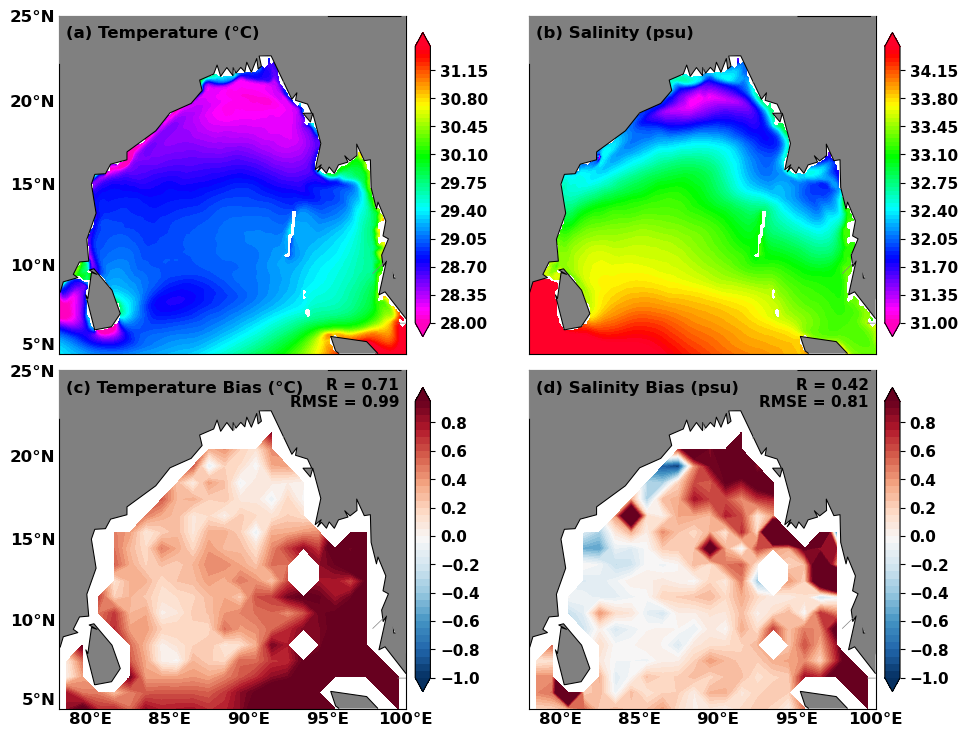

In [28]:
lon_clim = temp_clim.LON_RHO577_841.values
lat_clim = temp_clim.LAT_RHO379_689.values
lon2d_clim, lat2d_clim = np.meshgrid(lon_clim, lat_clim)

# ---- For bias (WOA grid) ----
lon_bias = bias_temp['LON211_300'].values
lat_bias = bias_temp['LAT61_120'].values
lon2d_bias, lat2d_bias = np.meshgrid(lon_bias, lat_bias)

cmap_abs = "gist_rainbow_r"
cmap_bias = "RdBu_r"

# ✅ R and RMSE values
corr_values = [0.71, 0.42]
rmse_values = [0.99, 0.81]

levels_bias = np.arange(-1.,1., 0.05)
levels_temp = np.arange(28, 31.5, 0.05)
levels_salt = np.arange(31, 34.5, 0.05)

fig, ax = plt.subplots(2,2, figsize=(12,9))
plt.subplots_adjust(wspace=0.02, hspace=0.05)

# Basemap
m = Basemap(
    projection='merc',
    resolution='c',
    llcrnrlat=4.5,
    urcrnrlat=25.1,
    llcrnrlon=78,
    urcrnrlon=100
)

# Convert grids
lon_c, lat_c = m(lon2d_clim, lat2d_clim)
lon_b, lat_b = m(lon2d_bias, lat2d_bias)
# Colorbars


        
# Plot panels
p1 = plot_map(ax[0,0], m, temp_clim['TEMP'].values,lon_c, lat_c, cmap_abs, levels_temp,extend='both', map_style='contour',show_lat=True, show_lon=False)

p2 = plot_map(ax[0,1], m, salt_clim['SALT'].values,lon_c, lat_c, cmap_abs, levels_salt,extend='both', map_style='contour',show_lat=False, show_lon=False)

p3 = plot_map(ax[1,0], m, bias_temp.values,lon_b, lat_b, cmap_bias, levels_bias,extend='both', map_style='contour',show_lat=True, show_lon=True)

p4 = plot_map(ax[1,1], m, bias_salt.values,lon_b, lat_b, cmap_bias, levels_bias,extend='both', map_style='contour',show_lat=False, show_lon=True)

ax[0,0].text(0.02,0.97,"(a) Temperature (\u00B0C)", transform=ax[0,0].transAxes, fontsize=12, fontweight='bold', va='top', zorder=10)

ax[0,1].text(0.02,0.97,"(b) Salinity (psu)", transform=ax[0,1].transAxes, fontsize=12, fontweight='bold', va='top', zorder=10)

ax[1,0].text(0.02,0.97,"(c) Temperature Bias (\u00B0C)", transform=ax[1,0].transAxes, fontsize=12, fontweight='bold', va='top', zorder=10)

ax[1,1].text(0.02,0.97,"(d) Salinity Bias (psu)", transform=ax[1,1].transAxes, fontsize=12, fontweight='bold', va='top', zorder=10)

cbar1 = plt.colorbar(p1, ax=ax[0,0], shrink=0.90, pad=0.02)
cbar2 = plt.colorbar(p2, ax=ax[0,1], shrink=0.90, pad=0.02)
cbar3 = plt.colorbar(p3, ax=ax[1,0], shrink=0.90, pad=0.02)
cbar4 = plt.colorbar(p4, ax=ax[1,1], shrink=0.90, pad=0.02)
# Make tick labels bold
for cb in [cbar1, cbar2, cbar3, cbar4]:
    cb.ax.tick_params(labelsize=11)
    for tick in cb.ax.get_yticklabels():
        tick.set_fontweight('bold')

# Panel (c) statistics
ax[1,0].text(0.98, 0.98,
             f"R = {corr_values[0]:.2f}\nRMSE = {rmse_values[0]:.2f}", 
             transform=ax[1,0].transAxes,
             fontsize=11, fontweight='bold',
             ha='right', va='top',zorder=100)
#              bbox=dict(facecolor='black', alpha=0.7, edgecolor='none'))

# Panel (d) statistics
ax[1,1].text(0.98, 0.98,
             f"R = {corr_values[1]:.2f}\nRMSE = {rmse_values[1]:.2f}",
             transform=ax[1,1].transAxes,
             fontsize=11, fontweight='bold',
             ha='right', va='top',zorder=100)

# ============================
# SAVE FIGURE
# ============================
# plt.savefig("Temp_Salt_spatial_bias_maps.png",dpi=600, bbox_inches='tight')
plt.show()


In [29]:
# Model pCO2 data
ds1=xr.open_dataset('BoB_pCO2_Sur_80_14.nc') # TEMP1 variable
# print(ds1)
mod = ds1.sel(
    LON_RHO577_841=slice(78,100),
    LAT_RHO379_689=slice(4.5,24),
    TIME=slice('1980-01-15','2014-10-17') 
)
model_clim = mod.groupby('TIME.month').mean('TIME')
print(model_clim)

# XGBoost data 
ds2=xr.open_dataset('XGBoost_BoB_pCO2_V3.nc',decode_times=False) # spco2 variable

obs1 = ds2.sel( 
    Lon=slice(78,100),
    Lat=slice(4.5,24),
    # time=slice('1995-01-15','2014-10-17') 
)
# obs2 = obs1.groupby('time.month').mean('time')
obs1=obs1-27 # for normalization


<xarray.Dataset> Size: 6MB
Dimensions:         (month: 12, LAT_RHO379_689: 243, LON_RHO577_841: 265)
Coordinates:
  * LAT_RHO379_689  (LAT_RHO379_689) float32 972B 4.517 4.6 ... 23.88 23.96
  * LON_RHO577_841  (LON_RHO577_841) float32 1kB 78.0 78.08 ... 99.92 100.0
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    pCO2            (month, LAT_RHO379_689, LON_RHO577_841) float64 6MB 379.3...


In [30]:
oo = obs1['pCO2']
oo
oc = oo.mean(dim=['Time'], skipna=True)
oc.min(),oc.max(),oc.mean()
# model have low resolution that obserrvations so, observations need to regrid
obs_clim_regd = []
obs_clim_regd = obs1.interp(
    Lon=mod.LON_RHO577_841,
    Lat=mod.LAT_RHO379_689,
    method='nearest'
)
# print(obs_clim_regd)
obs_clim_regd.dims
# print(obs_clim_regd)

FrozenMappingWarningOnValuesAccess({'Time': 12, 'LAT_RHO379_689': 243, 'LON_RHO577_841': 265})

In [31]:
# Only rename if 'Time' is still present
if 'Time' in obs_clim_regd.dims or 'Time' in obs_clim_regd.coords:
    obs_clim_regd = obs_clim_regd.rename({'Time': 'month'})
obs_clim_regd = obs_clim_regd.assign_coords(month=model_clim['month'])
# print(obs_clim_regd)
obs_var = obs_clim_regd['pCO2'] ## 'tos' : temperature 'sos' : salinity
mod_var = model_clim['pCO2']  ## 'TEMP' : temperature and 'SALT' : salinity
print(obs_var.shape),print(mod_var.shape)
# print(obs_var.dims),print(mod_var.dims)

(12, 243, 265)
(12, 243, 265)


(None, None)

In [32]:
    # rest of your plotting code...
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import pearsonr
import xskillscore as xs
# Example data variables:
# obs_var: (month, lat, lon)
# mod_var: (month, lat, lon)

# --- 1. Compute climatological means
obs_mean = obs_var.mean(dim='month')
mod_mean = mod_var.mean(dim='month')

corr_p = xs.pearson_r(mod_var, obs_var, dim='month')
bias_p = mod_var-obs_var

print(obs_mean.dims),print(mod_mean.dims),print(corr_p.dims),print(bias_p.dims)

('LAT_RHO379_689', 'LON_RHO577_841')
('LAT_RHO379_689', 'LON_RHO577_841')
('LAT_RHO379_689', 'LON_RHO577_841')
('month', 'LAT_RHO379_689', 'LON_RHO577_841')


(None, None, None, None)

In [33]:
rmse_map = np.sqrt(((mod_mean - obs_mean) ** 2))
print(rmse_map.mean())
# bias_time = (mod_var - obs_var).mean(dim=('LAT_RHO379_689', 'LON_RHO577_841'))
bias_time = (mod_var - obs_var).mean(dim='month')

# bias_time = mod_var - obs_var
print(bias_time.mean())
print(bias_time), print(mod_var.mean()),print(obs_var.mean())

<xarray.DataArray 'pCO2' ()> Size: 8B
array(13.04678049)
<xarray.DataArray 'pCO2' ()> Size: 8B
array(12.8297565)
<xarray.DataArray 'pCO2' (LAT_RHO379_689: 243, LON_RHO577_841: 265)> Size: 515kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * LAT_RHO379_689  (LAT_RHO379_689) float32 972B 4.517 4.6 ... 23.88 23.96
  * LON_RHO577_841  (LON_RHO577_841) float32 1kB 78.0 78.08 ... 99.92 100.0
    Lon             (LON_RHO577_841) float32 1kB 78.0 78.08 ... 99.92 100.0
    Lat             (LAT_RHO379_689) float32 972B 4.517 4.6 ... 23.88 23.96
<xarray.DataArray 'pCO2' ()> Size: 8B
array(372.13381316)
<xarray.DataArray 'pCO2' ()> Size: 8B
array(357.31228638)


(None, None, None)

In [34]:
# print(obs_var),print(mod_var)
print("Obs NaN count:", obs_var.isnull().sum().item())
print("Mod NaN count:", mod_var.isnull().sum().item())
nan_obs = obs_var.isnull()
nan_mod = mod_var.isnull()

same_nan_mask = nan_obs.equals(nan_mod)

print("Are NaN locations identical?", same_nan_mask)
common_mask = (~obs_var.isnull()) & (~mod_var.isnull())

obs_clean = obs_var.where(common_mask)
mod_clean = mod_var.where(common_mask)


Obs NaN count: 382027
Mod NaN count: 296376
Are NaN locations identical? False


In [35]:
# Bias
bias_p = (mod_clean - obs_clean).mean(dim='month')

# Correlation
corr_p = xr.corr(mod_clean, obs_clean, dim='month')

# p-Value
pval_p = xs.pearson_r_p_value(mod_clean, obs_clean, dim='month')

# RMSE
rmse_p = np.sqrt(((mod_clean - obs_clean) ** 2).mean(dim='month'))

print(bias_p.mean()),print(rmse_p.mean()),print(corr_p.mean()),print(pval_p.mean())

<xarray.DataArray 'pCO2' ()> Size: 8B
array(12.8297565)
<xarray.DataArray 'pCO2' ()> Size: 8B
array(19.09750444)
<xarray.DataArray 'pCO2' ()> Size: 8B
array(0.63643126)
<xarray.DataArray 'pCO2' ()> Size: 8B
array(0.05031482)


(None, None, None, None)

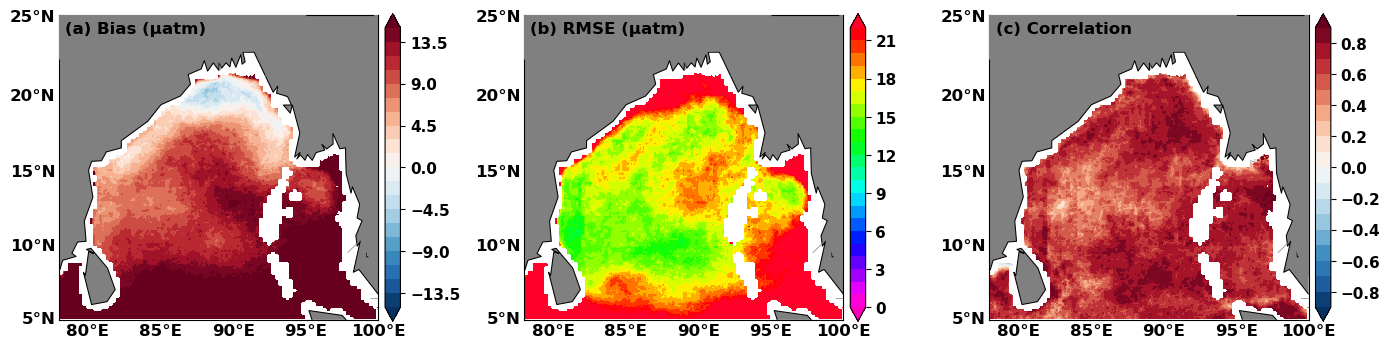

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

datasets = [bias_p, rmse_p, corr_p]

lon_name = 'LON_RHO577_841'
lat_name = 'LAT_RHO379_689'

levels_bias = np.linspace(-15,15.01,21)
levels_rmse = np.linspace(0,22,23)
levels_corr = np.linspace(-0.9,0.9,19)

levels_list = [levels_bias, levels_rmse, levels_corr]

cmaps = ['RdBu_r','gist_rainbow_r','RdBu_r']

titles = [
'(a) Bias (μatm)',
'(b) RMSE (μatm)',
'(c) Correlation'
]

# ================= FIGURE =================
fig, ax = plt.subplots(1,3, figsize=(14,10))
plt.subplots_adjust(hspace=0.07)

for i, data in enumerate(datasets):

    lon = data[lon_name].values
    lat = data[lat_name].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    z = data.values

    # Basemap
    m = Basemap(
        projection='merc',
        resolution='c',
        llcrnrlat=4.95,
        urcrnrlat=25.1,
        llcrnrlon=78,
        urcrnrlon=100
    )

    x, y = m(lon2d, lat2d)

    # Show longitude only in last panel
    show_lon = True if i in [0,1,2] else False

    cf = plot_map(
        ax[i], m, z, x, y,
        cmap=cmaps[i],
        levels=levels_list[i],
        extend='both',
        map_style='contour',
        show_lat=True,
        show_lon=show_lon
    )

    # Panel titles
    ax[i].text(
        0.02,0.98,
        titles[i],
        transform=ax[i].transAxes,
        fontsize=12,
        fontweight='bold',
        ha='left',
        va='top',
        zorder=100
    )

    # Colorbar
    cbar = plt.colorbar(
        cf,
        ax=ax[i],
        orientation='vertical',
        fraction=0.045,
        pad=0.02
    )

    cbar.ax.tick_params(labelsize=11)

    for tick in cbar.ax.get_yticklabels():
        tick.set_fontweight('bold')

plt.tight_layout()
# ============================
# SAVE FIGURE
# ============================
# plt.savefig("pCO2_spatial_bias_RMSE_r_maps.png",dpi=600, bbox_inches='tight')
plt.show()

In [37]:
# ROMS ensemble climatological output of Historical, NF, MF and Far-Future data
hs=xr.open_dataset('pCO2_Ensemble_Clim_HIS.nc')
history = hs.sel(
    LON_RHO=slice(78,100),
    LAT_RHO=slice(5,25),
    )
history_clim = history.mean(dim='month')
# print(history_clim)

nf=xr.open_dataset('pCO2_Ensemble_Clim_NF.nc')
nfuture = nf.sel(
    LON_RHO=slice(78,100),
    LAT_RHO=slice(5,25),
    )
# print(future)
nfuture_clim = nfuture.mean(dim='month')
# print(nfuture_clim)
delta_nf = ((nfuture_clim-history_clim)/history_clim)*100
# print(delta_nf.min()),print(delta_nf.max())

mf=xr.open_dataset('pCO2_Ensemble_Clim_MF.nc')
mfuture = mf.sel(
    LON_RHO=slice(78,100),
    LAT_RHO=slice(5,25),
    )
# print(future)
mfuture_clim = mfuture.mean(dim='month')
# print(mfuture_clim)
delta_mf = ((mfuture_clim-history_clim)/history_clim)*100
# print(delta_mf.min()),print(delta_mf.max())

ff=xr.open_dataset('pCO2_Ensemble_Clim_FF.nc')
future = ff.sel(
    LON_RHO=slice(78,100),
    LAT_RHO=slice(5,25),
    )
# print(future)
future_clim = future.mean(dim='month')
# print(future_clim)
delta_ff = ((future_clim-history_clim)/history_clim)*100
# print(delta_ff.min()),print(delta_ff.max())

In [38]:
pco2_range = nfuture.max() - delta_nf.min()
# print(delta_nf.min()),print(delta_nf.max()),print(pco2_range)

pco2_range = delta_mf.max() - delta_mf.min()
# print(delta_mf.min()),print(delta_mf.max()),print(pco2_range)

pco2_range = delta_ff.max() - delta_ff.min()
# print(delta_ff.min()),print(delta_ff.max()),print(pco2_range)

In [39]:
import numpy as np
from matplotlib import colors

l_nf  = np.arange(15,22,0.2)
l_nf1 = np.arange(22,41,20)
l_mf  = np.arange(42,63,1)
l_mf1 = np.arange(63,99,35)
l_ff  = np.arange(99,148,1)

levels_per = np.concatenate((l_nf, l_nf1, l_mf, l_mf1, l_ff))
levels_per_color = colors.BoundaryNorm(levels_per, ncolors=256)

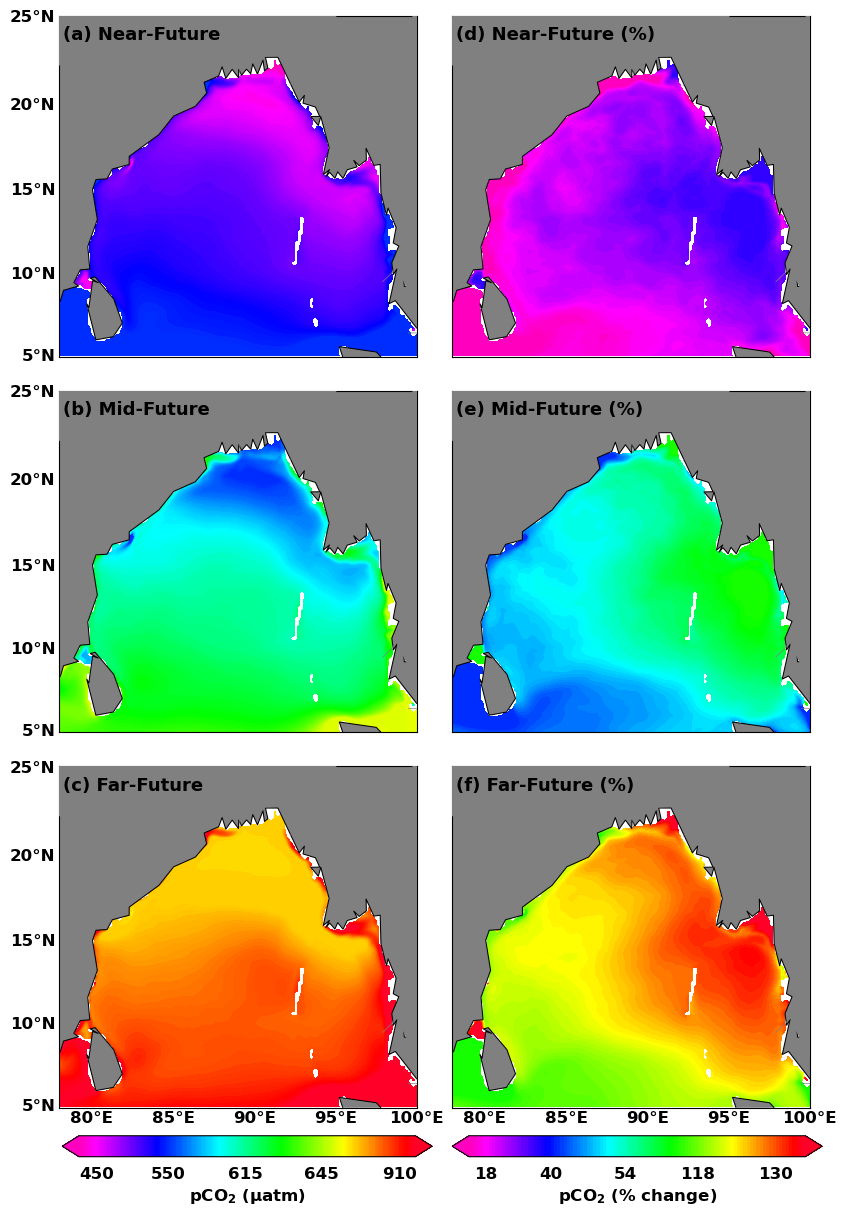

In [41]:
def plot_map(ax, map, data, lon, lat, cmap,levels=None, vmin=None, vmax=None, extend='neither',norm=None,map_style=None,show_lat=True, show_lon=True):
    if map_style=='contour':
        cf = map.contourf(lon, lat, data, levels=levels, norm=norm,cmap=cmap, extend=extend, ax=ax)
    elif  map_style=='pc':
        cf = map.pcolormesh(lon,lat,data,norm=norm, cmap=cmap,shading='gouraud',edgecolors ='face',ax=ax)
    else:
        print('Not possible')
    map.fillcontinents(color='grey', lake_color='grey', ax=ax)
    map.drawcoastlines(ax=ax, linewidth=0.75)
    map.drawcountries(color='grey', ax=ax)
    map.drawstates(color='grey', ax=ax)
#     map.drawmeridians(np.arange(40, 120, 5), labels=[0, 0, 0, 1], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
#     map.drawparallels(np.arange(-30, 31, 5), labels=[1, 0, 0, 0], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
    regions = {
        'china': [(106, -5), (120, -8.5), (120, 29.5), (100, 29.5), (99, 10),
                  (104, 0), (106.5, -7), (115, -8.5), (120, -8)],
        'victoria': [(31, -20), (35, -20), (35, 1), (31, 1), (31, -20)],
        'india1': [(69.5, 22), (95, 23), (95, 28), (69.5, 28), (69.5, 22)],
        'india2': [(65, 26), (70, 26), (70, 29), (65, 29), (65, 26)],
        'uae': [(30.5, 12), (43, 12), (43, 29.9), (30.5, 29.9), (30.5, 12)],
        'uae1': [(30.5, 23), (56.5, 23), (56.5, 29.9), (30.5, 29.9), (30.5, 23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[map(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)
        
        
    if show_lat:
        paralles = map.drawparallels(np.arange(5,26,5),
                              labels=[1,0,0,0],
                              fontsize=12,
                              color='none',
                              ax=ax)
    else:
        paralles = map.drawparallels(np.arange(5,26,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)

    # Longitude labelso
    if show_lon:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,1],
                          fontsize=12,
                          color='none',
                          ax=ax)
    else:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)
    # Make labels bold
    for m in meridians.values():
        for t in m[1]:
            t.set_fontweight('bold')

    for p in paralles.values():
        for t in p[1]:
            t.set_fontweight('bold')
   
    return cf




# ---------------- FIGURE LAYOUT (3 rows × 2 columns) ----------------
fig, ax = plt.subplots(3, 2, figsize=(10, 14))
plt.subplots_adjust(hspace= 0.1, wspace=0.03, bottom=0.1)
# plt.subplots_adjust(hspace=0.06, wspace=0.03, bottom=0.1)
ax = ax.ravel()

# -----------------------------------------------------
# Basemap settings
# -----------------------------------------------------
# m = Basemap(
#     projection='merc', resolution='c',
#     llcrnrlat=4.91, urcrnrlat=24.1,
#     llcrnrlon=78, urcrnrlon=100
# )
m = Basemap(projection='merc',resolution='c',llcrnrlat=4.95,urcrnrlat=25.1,llcrnrlon=78,urcrnrlon=100)
lon2d, lat2d = np.meshgrid(history_clim.LON_RHO, history_clim.LAT_RHO)
lon, lat = m(lon2d, lat2d)

# colormaps
cmap_abs = "gist_rainbow_r"
levels_nf = np.arange(440, 490, 1)
levels_nf1 = np.arange(490,585,100)
levels_mf = np.arange(585, 650, 0.7)
levels_mf1 = np.arange(650,885,20)
levels_ff = np.arange(885, 920, 1)
levels_con = np.concatenate((levels_nf, levels_nf1, levels_mf, levels_mf1, levels_ff))
norm_con = colors.BoundaryNorm(levels_con, ncolors=256)

levels_ndel = np.arange(17.5, 19.5, 0.1)
levels_ndel1 = np.arange(19.5,50,4)
levels_mdel = np.arange(50, 57, 0.2)
levels_mdel1 = np.arange(57,115,60)
levels_fdel = np.arange(115, 135, 0.5)
levels_per = np.concatenate((levels_ndel, levels_ndel1, levels_mdel, levels_mdel1, levels_fdel))
norm_del = colors.BoundaryNorm(levels_per, ncolors=256)


# -----------------------------------------------------
# Get min/max values for consistent color scale (pCO₂)
# -----------------------------------------------------
vmin_pco2 = min(np.min(nfuture_clim['pCO2'].values), np.min(mfuture_clim['pCO2'].values), np.min(future_clim['pCO2'].values))
vmax_pco2 = max(np.max(nfuture_clim['pCO2'].values), np.max(mfuture_clim['pCO2'].values), np.max(future_clim['pCO2'].values))

# Get min/max values for consistent color scale (delta pCO₂)
# -----------------------------------------------------
vmin_delta = min(np.min(delta_nf['pCO2'].values), np.min(delta_mf['pCO2'].values), np.min(delta_ff['pCO2'].values))
vmax_delta = max(np.max(delta_nf['pCO2'].values), np.max(delta_mf['pCO2'].values), np.max(delta_ff['pCO2'].values))

# -----------------------------------------------------
# PLOTS
# -----------------------------------------------------
p1 = plot_map(ax[0], m, nfuture_clim['pCO2'].values, lon, lat,cmap=cmap_abs, levels=levels_con, extend='both',norm=norm_con, vmin=vmin_pco2, vmax=vmax_pco2,map_style='contour', show_lat=True, show_lon=False)
p2 = plot_map(ax[2], m, mfuture_clim['pCO2'].values, lon, lat,cmap=cmap_abs, levels=levels_con, extend='both',norm=norm_con, vmin=vmin_pco2, vmax=vmax_pco2,map_style='contour', show_lat=True, show_lon=False)
p3 = plot_map(ax[4], m, future_clim['pCO2'].values, lon, lat,cmap=cmap_abs, levels=levels_con, extend='both',norm=norm_con, vmin=vmin_pco2, vmax=vmax_pco2,map_style='contour', show_lat=True, show_lon=True)

q1 = plot_map(ax[1], m, delta_nf['pCO2'].values, lon, lat,cmap=cmap_abs, levels=levels_per, extend='both',norm=norm_del, vmin=vmin_delta, vmax=vmax_delta,map_style='contour', show_lat=False, show_lon=False)
q2 = plot_map(ax[3], m, delta_mf['pCO2'].values, lon, lat,cmap=cmap_abs, levels=levels_per, extend='both',norm=norm_del, vmin=vmin_delta, vmax=vmax_delta,map_style='contour', show_lat=False, show_lon=False)
q3 = plot_map(ax[5], m, delta_ff['pCO2'].values, lon, lat,cmap=cmap_abs, levels=levels_per, extend='both',norm=norm_del, vmin=vmin_delta, vmax=vmax_delta,map_style='contour', show_lat=False, show_lon=True)


# --- Absolute pCO₂ colorbar (for first column) ---
cbar_ax1 = fig.add_axes([0.14, 0.065, 0.37, 0.015])  # [left, bottom, width, height]
cbar1 = fig.colorbar(p1, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label(r"$\mathbf{pCO_{2}\ (\mu atm)}$", fontsize=12)
cbar1.ax.tick_params(labelsize=12)

# --- % Difference colorbar (for second column) ---
cbar_ax2 = fig.add_axes([0.53, 0.065, 0.37, 0.015])  # [left, bottom, width, height]
cbar2 = fig.colorbar(q1, cax=cbar_ax2, orientation='horizontal',format='%.0f')
cbar2.set_label(r"$\mathbf{pCO_{2}}$ (% change)", fontsize=12, fontweight = 'bold')


cbar1.set_ticks([450, 550, 615, 645,910])
cbar1.ax.tick_params(labelsize=12)
for tick in cbar1.ax.get_xticklabels():
    tick.set_fontweight('bold')
cbar1.ax.xaxis.set_ticks_position('none')

cbar2.set_ticks([18, 40,  54, 118, 130])
cbar2.ax.tick_params(labelsize=12)
for tick in cbar2.ax.get_xticklabels():
    tick.set_fontweight('bold')
cbar2.ax.xaxis.set_ticks_position('none')

# -----------------------------------------------------
# PANEL LABELS
# -----------------------------------------------------
titles = {0: "Near-Future", 2: "Mid-Future", 4: "Far-Future", 1: "Near-Future (%)", 3: "Mid-Future (%)", 5: "Far-Future (%)"}
panel_labels = {0: "(a) Near-Future", 2: "(b) Mid-Future", 4: "(c) Far-Future", 1: "(d) Near-Future (%)", 3: "(e) Mid-Future (%)", 5: "(f) Far-Future (%)"}

for idx, title in titles.items():
    ax[idx].text(0.01, 0.97, panel_labels[idx],
                 transform=ax[idx].transAxes,
                 fontsize=13, fontweight='bold',
                 va='top', ha='left',zorder=100)

# plt.savefig('NF_MF_FF_pCO2_Percentage_spatial_map.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
plt.show()

In [42]:
### HISTORICAL DRIVERS
slope_his = xr.open_dataset('Original_pCO2_slope1_HIS.nc').slope
### NEAR-FUTURE DRIVERS
slope_nf = xr.open_dataset('Original_pCO2_slope1_NF.nc').slope
### MID-FUTURE DRIVERS
slope_mf = xr.open_dataset('Original_pCO2_slope_MF.nc').slope
### FAR-FUTURE DRIVERS
slope_ff = xr.open_dataset('Original_pCO2_slope_FF.nc').slope

In [43]:
print(slope_ff.dims),print(slope_mf.dims),print(slope_nf.dims),print(slope_his.dims)
slope_ff.shape, slope_mf.shape, slope_nf.shape, slope_his.shape


('LAT_RHO', 'LON_RHO')
('LAT_RHO', 'LON_RHO')
('LAT_RHO', 'LON_RHO')
('LAT_RHO', 'LON_RHO')


((310, 301), (310, 301), (250, 265), (250, 265))

In [44]:
lon1=slope_his['LON_RHO']
lat1=slope_his['LAT_RHO']
lond, latd = np.meshgrid(lon1, lat1)

lon2=slope_mf['LON_RHO']
lat2=slope_mf['LAT_RHO']
lon2d, lat2d = np.meshgrid(lon2, lat2)

In [45]:
levels_hs = np.arange(1.82,2.4,0.02)
levels_hs1 = np.arange(2.4,2.75,1)
levels_nf = np.arange(2.75,3.35,0.01)
levels_nf1 = np.arange(3.35,6.88,5)
levels_mf = np.arange(6.88,7.45,0.005)
levels_mf1 = np.arange(7.45,11.8,5)
levels_ff = np.arange(11.8,13,0.03)
levels_con = np.concatenate((levels_hs,levels_hs1,levels_nf,levels_nf1,levels_mf,levels_mf1,levels_ff))

norm_con = colors.BoundaryNorm(levels_con, ncolors=256)


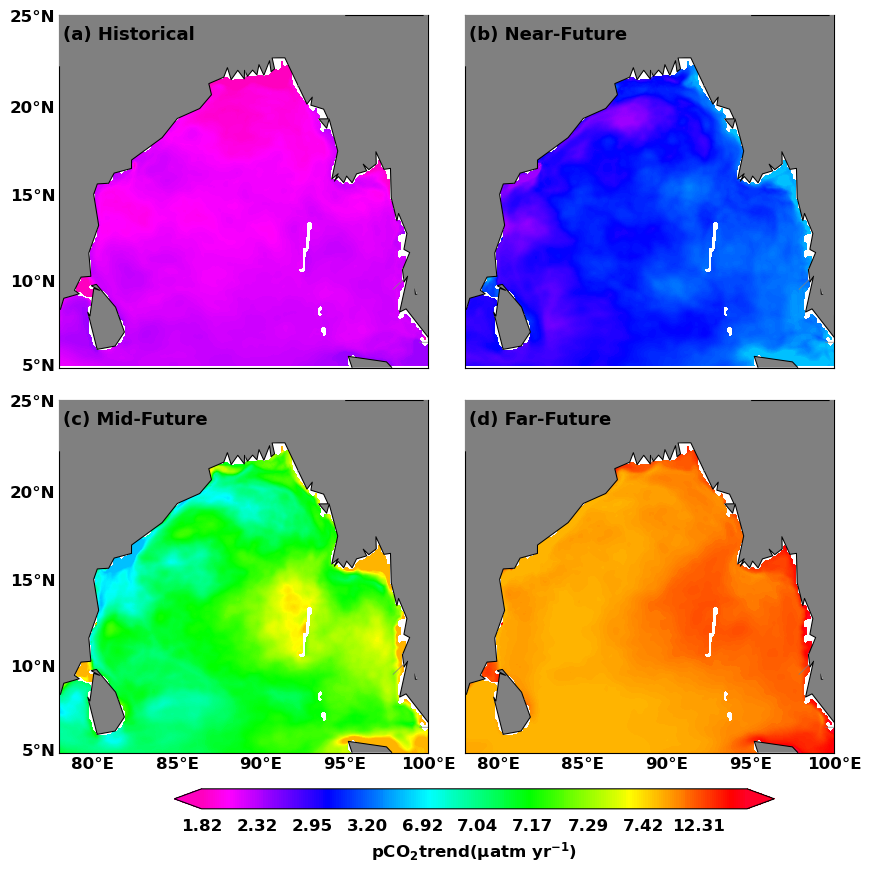

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cmocean
from matplotlib import colors

# -----------------------------------------------------
# Function for individual subplot
# -----------------------------------------------------
def plot_map(ax, m, data, lon, lat, cmap,
             levels=None, norm=None, extend='neither',
             map_style='contour', show_lat=True, show_lon=True):

    plt.sca(ax)

    # convert to map projection coordinates
    x, y = m(lon, lat)

    # plotting
    if map_style == 'contour':
        cf = m.contourf(x, y, data,
                        levels=levels,
                        cmap=cmap,
                        norm=norm,
                        extend=extend)

    elif map_style == 'pc':
        cf = m.pcolormesh(x, y, data,
                          cmap=cmap,
                          norm=norm,
                          shading='auto')

    else:
        raise ValueError("map_style must be 'contour' or 'pc'")

    # land and coast
    m.fillcontinents(color='grey', lake_color='grey')
    m.drawcoastlines(linewidth=0.75)
    m.drawcountries(color='grey')
    m.drawstates(color='grey')

    # -------------------------------------------------
    # Mask unwanted regions
    # -------------------------------------------------
    regions = {
        'china': [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),
                  (104,0),(106.5,-7),(115,-8.5),(120,-8)],
        'victoria': [(31,-20),(35,-20),(35,1),(31,1),(31,-20)],
        'india1': [(69.5,22),(95,23),(95,28),(69.5,28),(69.5,22)],
        'india2': [(65,26),(70,26),(70,29),(65,29),(65,26)],
        'uae': [(30.5,12),(43,12),(43,29.9),(30.5,29.9),(30.5,12)],
        'uae1': [(30.5,23),(56.5,23),(56.5,29.9),(30.5,29.9),(30.5,23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[m(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)

    # -------------------------------------------------
    # Latitude lines
    # -------------------------------------------------
    if show_lat:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[1,0,0,0],
                                    fontsize=12,
                                    color='none')
    else:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[0,0,0,0],
                                    color='none')

    # -------------------------------------------------
    # Longitude lines
    # -------------------------------------------------
    if show_lon:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,1],
                                     fontsize=12,
                                     color='none')
    else:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,0],
                                     color='none')

    # Bold labels
    for m1 in meridians.values():
        for t in m1[1]:
            t.set_fontweight('bold')

    for p1 in parallels.values():
        for t in p1[1]:
            t.set_fontweight('bold')

    return cf


# -----------------------------------------------------
# FIGURE LAYOUT
# -----------------------------------------------------
fig, ax = plt.subplots(2,2, figsize=(10,10))
plt.subplots_adjust(hspace=0, wspace=0.1)

ax = ax.ravel()

# -----------------------------------------------------
# Basemap
# -----------------------------------------------------
m = Basemap(projection='merc',
            resolution='c',
            llcrnrlat=4.91,
            urcrnrlat=25.1,
            llcrnrlon=78,
            urcrnrlon=100)

# -----------------------------------------------------
# Color settings
# -----------------------------------------------------
cmap_abs = "gist_rainbow_r"

vmin_pco2 = 2
vmax_pco2 = 13

# norm_con = colors.Normalize(vmin=vmin_pco2, vmax=vmax_pco2)

# -----------------------------------------------------
# PLOTS
# -----------------------------------------------------
p1 = plot_map(ax[0], m, slope_his, lond, latd,
              cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              map_style='contour',
              show_lat=True, show_lon=False)

p2 = plot_map(ax[1], m, slope_nf, lond, latd,
              cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              map_style='contour',
              show_lat=False, show_lon=False)

p3 = plot_map(ax[2], m, slope_mf, lon2d, lat2d,
              cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              map_style='contour',
              show_lat=True, show_lon=True)

p4 = plot_map(ax[3], m, slope_ff, lon2d, lat2d,
              cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              map_style='contour',
              show_lat=False, show_lon=True)


# -----------------------------------------------------
# COLORBAR
# -----------------------------------------------------
cbar_ax = fig.add_axes([0.24,0.07,0.6,0.02])

cbar = fig.colorbar(p1,
                    cax=cbar_ax,
                    orientation='horizontal')

cbar.set_label(r"$\mathbf{pCO_{2} trend (\mu atm \ yr^{-1})}$", fontsize=12, fontweight='bold')
# cbar1.set_label(r"$\mathbf{pCO_{2}\ (\mu atm)}$", fontsize=12)

cbar.ax.tick_params(labelsize=12)

for tick in cbar.ax.get_xticklabels():
    tick.set_fontweight('bold')

cbar.ax.xaxis.set_ticks_position('none')


# -----------------------------------------------------
# PANEL LABELS
# -----------------------------------------------------
panel_labels = {
0:"(a) Historical",
1:"(b) Near-Future",
2:"(c) Mid-Future",
3:"(d) Far-Future"
}

for i in range(4):
    ax[i].text(0.01,0.97,
               panel_labels[i],
               transform=ax[i].transAxes,
               fontsize=13,
               fontweight='bold',
               va='top',
               ha='left',zorder=100)

# -----------------------------------------------------
# SAVE FIGURE
# -----------------------------------------------------
# plt.savefig('pCO2_trend_allperiodsa.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
    
plt.show()


del CMIP_GF, CMIP_UK, CMIP_CN

In [48]:
# # CMIP6 model data
### needs to update data files here for Future Downscaled influence to understand  .sel(LON_RHO=slice(30,119.5),LAT_RHO=slice(-31,31)) 
CMIP_GF = xr.open_dataset('CMIP_GFDL_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_CN1 = xr.open_dataset('CMIP_CNRM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_UK1 = xr.open_dataset('CMIP_UKESM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
# CMIP_GF,CMIP_CN,CMIP_UK,  

In [50]:
# # model have low resolution that obserrvations so, observations need to regrid
CMIP_UK = []
CMIP_UK = CMIP_UK1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)
CMIP_CN = []
CMIP_CN = CMIP_CN1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)


# print(CMIP_GF),print(CMIP_UK), print(CMIP_CN)
CMIP_GF.dims,CMIP_UK.dims,CMIP_CN.dims


(('TIME', 'LAT_RHO', 'LON_RHO'),
 ('TIME', 'LAT_RHO', 'LON_RHO'),
 ('TIME', 'LAT_RHO', 'LON_RHO'))

In [51]:
# print(CMIP_GF.shape, CMIP_UK.shape, CMIP_CN.shape)

# print(CMIP_GF.dims)
# print(CMIP_UK.dims)
# print(CMIP_CN.dims)
# print(CMIP_GF.coords)
# print(CMIP_UK.coords)
# print(CMIP_CN.coords)

import xarray as xr

CMIP_CN['TIME'] = xr.cftime_range(
    start=str(CMIP_CN.TIME.values[0])[:10],
    periods=len(CMIP_CN.TIME),
    freq="MS"
)
# print(CMIP_CN.coords)
CMIP_CN = CMIP_CN.assign_coords(TIME=CMIP_GF.TIME)
CMIP_UK = CMIP_UK.assign_coords(TIME=CMIP_GF.TIME)
# print(CMIP_CN.coords)

In [52]:
import xarray as xr

CMIP_GF, CMIP_UK, CMIP_CN = xr.align(CMIP_GF, CMIP_UK, CMIP_CN)
# CMIP_GF, CMIP_UK, CMIP_CN

In [53]:
common_mask = (~CMIP_GF.isnull()) & (~CMIP_UK.isnull()) & (~CMIP_CN.isnull())

CMIP_GF = CMIP_GF.where(common_mask)
CMIP_UK = CMIP_UK.where(common_mask)
CMIP_CN = CMIP_CN.where(common_mask)

print("GFDL NaNs:", CMIP_GF.isnull().sum().item())
print("UKESM NaNs:", CMIP_UK.isnull().sum().item())
print("CNRM NaNs:", CMIP_CN.isnull().sum().item())

GFDL NaNs: 313632
UKESM NaNs: 313632
CNRM NaNs: 313632


In [54]:
CMIP_ens = xr.concat([CMIP_GF, CMIP_UK, CMIP_CN], dim='model').mean(dim='model')
# CMIP_ens

In [55]:
CMIP_ens_nf = CMIP_ens.sel(TIME=slice('2015','2040')).mean(dim='TIME')
CMIP_ens_mf = CMIP_ens.sel(TIME=slice('2041','2070')).mean(dim='TIME')
CMIP_ens_ff = CMIP_ens.sel(TIME=slice('2071','2100')).mean(dim='TIME')
CMIP_ens_hs = CMIP_ens.sel(TIME=slice('1980','2014')).mean(dim='TIME')

nf_per =((CMIP_ens_nf - CMIP_ens_hs)/CMIP_ens_hs)*100

mf_per =((CMIP_ens_mf - CMIP_ens_hs)/CMIP_ens_hs)*100

ff_per =((CMIP_ens_ff - CMIP_ens_hs)/CMIP_ens_hs)*100

In [56]:
nf_per =((CMIP_ens_nf - CMIP_ens_hs)/CMIP_ens_hs)*100

mf_per =((CMIP_ens_mf - CMIP_ens_hs)/CMIP_ens_hs)*100

ff_per =((CMIP_ens_ff - CMIP_ens_hs)/CMIP_ens_hs)*100

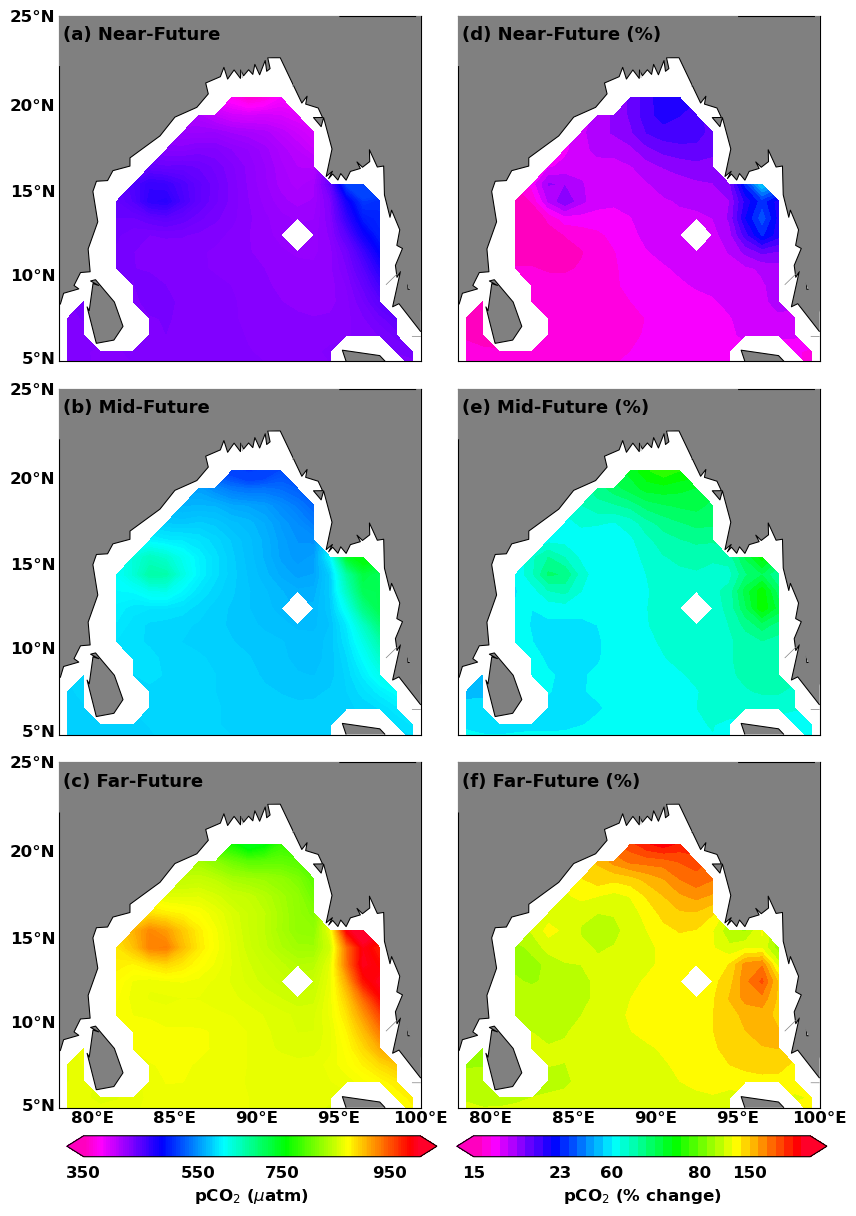

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cmocean  # for cmo.balance
from matplotlib import colors

def plot_map(ax, m, data, lon, lat, cmap,
             levels=None, norm=None, extend='neither',
             map_style='contour', show_lat=True, show_lon=True):

    plt.sca(ax)

    # convert to map projection coordinates
    x, y = m(lon, lat)

    # plotting
    if map_style == 'contour':
        cf = m.contourf(x, y, data,
                        levels=levels,
                        cmap=cmap,
                        norm=norm,
                        extend=extend)

    elif map_style == 'pc':
        cf = m.pcolormesh(x, y, data,
                          cmap=cmap,
                          norm=norm,
                          shading='auto')

    else:
        raise ValueError("map_style must be 'contour' or 'pc'")

    # land and coast
    m.fillcontinents(color='grey', lake_color='grey')
    m.drawcoastlines(linewidth=0.75)
    m.drawcountries(color='grey')
    m.drawstates(color='grey')

    # -------------------------------------------------
    # Mask unwanted regions
    # -------------------------------------------------
    regions = {
        'china': [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),
                  (104,0),(106.5,-7),(115,-8.5),(120,-8)],
        'victoria': [(31,-20),(35,-20),(35,1),(31,1),(31,-20)],
        'india1': [(69.5,22),(95,23),(95,28),(69.5,28),(69.5,22)],
        'india2': [(65,26),(70,26),(70,29),(65,29),(65,26)],
        'uae': [(30.5,12),(43,12),(43,29.9),(30.5,29.9),(30.5,12)],
        'uae1': [(30.5,23),(56.5,23),(56.5,29.9),(30.5,29.9),(30.5,23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[m(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)

    # -------------------------------------------------
    # Latitude lines
    # -------------------------------------------------
    if show_lat:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[1,0,0,0],
                                    fontsize=12,
                                    color='none')
    else:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[0,0,0,0],
                                    color='none')

    # -------------------------------------------------
    # Longitude lines
    # -------------------------------------------------
    if show_lon:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,1],
                                     fontsize=12,
                                     color='none')
    else:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,0],
                                     color='none')

    # Bold labels
    for m1 in meridians.values():
        for t in m1[1]:
            t.set_fontweight('bold')

    for p1 in parallels.values():
        for t in p1[1]:
            t.set_fontweight('bold')

    return cf

# ---------------- FIGURE LAYOUT (3 rows × 2 columns) ----------------
fig, ax = plt.subplots(3, 2, figsize=(10, 14))
plt.subplots_adjust(hspace=0.08, wspace=0.06, bottom=0.1)

ax = ax.ravel()

# -----------------------------------------------------
# Basemap settings
# -----------------------------------------------------
m = Basemap(
    projection='merc', resolution='c',
    llcrnrlat=4.91, urcrnrlat=25.1,
    llcrnrlon=78, urcrnrlon=100
)

lon2d, lat2d = np.meshgrid(CMIP_ens_nf.LON_RHO, CMIP_ens_nf.LAT_RHO)
lon = lon2d
lat = lat2d

# colormaps
cmap_abs = "gist_rainbow_r"
levels_nf = np.arange(350, 500,3)
levels_nf1 = np.arange(500,520,100)
levels_mf = np.arange(520, 680, 3)
levels_mf1 = np.arange(680,780,100)
levels_ff = np.arange(780, 1000, 3)
levels_con = np.concatenate((levels_nf, levels_nf1, levels_mf, levels_mf1, levels_ff))
norm_con = colors.BoundaryNorm(levels_con, ncolors=256)

levels_ndel = np.arange(18, 25, 0.5)
levels_ndel1 = np.arange(25,59,50)
levels_mdel = np.arange(59, 70, 1)
levels_mdel1 = np.arange(70,140,80)
levels_fdel = np.arange(140, 165, 2)
levels_per = np.concatenate((levels_ndel, levels_ndel1, levels_mdel, levels_mdel1, levels_fdel))
norm_del = colors.BoundaryNorm(levels_per, ncolors=256)


# -----------------------------------------------------
# Get min/max values for consistent color scale (pCO₂)
vmin_pco2 = 300
vmax_pco2 = 1100

# Get min/max values for consistent color scale (delta pCO₂)
vmin_per=20
vmax_per=160


p1 = plot_map(ax[0], m, CMIP_ens_nf, lon, lat,
              cmap=cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              show_lat=True, show_lon=False)

p2 = plot_map(ax[2], m, CMIP_ens_mf, lon, lat,
              cmap=cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              show_lat=True, show_lon=False)

p3 = plot_map(ax[4], m, CMIP_ens_ff, lon, lat,
              cmap=cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              show_lat=True, show_lon=True)

q1 = plot_map(ax[1], m, nf_per, lon, lat,
              cmap=cmap_abs,
              levels=levels_per,
              norm=norm_del,
              extend='both',
              show_lat=False, show_lon=False)

q2 = plot_map(ax[3], m, mf_per, lon, lat,
              cmap=cmap_abs,
              levels=levels_per,
              norm=norm_del,
              extend='both',
              show_lat=False, show_lon=False)

q3 = plot_map(ax[5], m, ff_per, lon, lat,
              cmap=cmap_abs,
              levels=levels_per,
              norm=norm_del,
              extend='both',
              show_lat=False, show_lon=True)
# -----------------------------------------------------
# COLORBARS
# -----------------------------------------------------

# --- Absolute pCO₂ colorbar (for first column) ---
cbar_ax1 = fig.add_axes([0.14, 0.065, 0.37, 0.015])  # [left, bottom, width, height]
cbar1 = fig.colorbar(p1, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label("pCO$_2$ ($\mu$atm)", fontsize=12, fontweight = 'bold')
cbar1.ax.tick_params(labelsize=12)

# --- % Difference colorbar (for second column) ---
cbar_ax2 = fig.add_axes([0.53, 0.065, 0.37, 0.015])  # [left, bottom, width, height]
cbar2 = fig.colorbar(q1, cax=cbar_ax2, orientation='horizontal',format='%.0f')
cbar2.set_label("pCO$_2$ (% change)", fontsize=12, fontweight = 'bold')


cbar1.set_ticks([350, 550, 750,950])
cbar1.ax.tick_params(labelsize=12)
for tick in cbar1.ax.get_xticklabels():
    tick.set_fontweight('bold')
cbar1.ax.xaxis.set_ticks_position('none')

cbar2.set_ticks([15, 23,  60, 80, 150])
cbar2.ax.tick_params(labelsize=12)
for tick in cbar2.ax.get_xticklabels():
    tick.set_fontweight('bold')
cbar2.ax.xaxis.set_ticks_position('none')
# -----------------------------------------------------
# PANEL LABELS
# -----------------------------------------------------
titles = {0: "Near-Future", 2: "Mid-Future", 4: "Far-Future", 1: "Near-Future (%)", 3: "Mid-Future (%)", 5: "Far-Future (%)"}
panel_labels = {0: "(a) Near-Future", 2: "(b) Mid-Future", 4: "(c) Far-Future", 1: "(d) Near-Future (%)", 3: "(e) Mid-Future (%)", 5: "(f) Far-Future (%)"}

for idx, title in titles.items():
    ax[idx].text(0.01, 0.97, panel_labels[idx],
                 transform=ax[idx].transAxes,
                 fontsize=13, fontweight='bold',
                 va='top', ha='left',zorder=100)

# plt.savefig('CMIP_Org_NF_MF_FF_pCO2_Percentage_spatial_map.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         


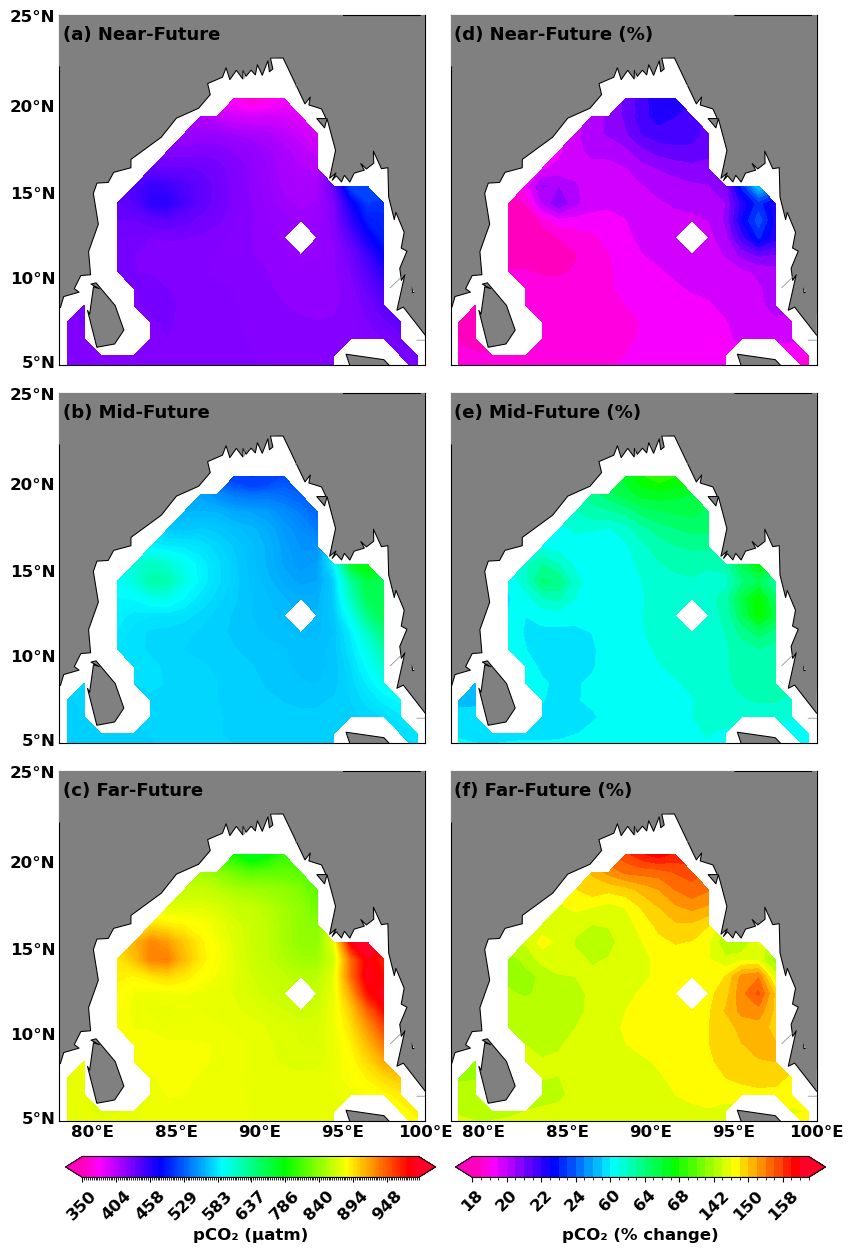

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cmocean  # for cmo.balance
from matplotlib import colors

def plot_map(ax, m, data, lon, lat, cmap,
             levels=None, norm=None, extend='neither',
             map_style='contour', show_lat=True, show_lon=True):

    plt.sca(ax)

    # convert to map projection coordinates
    x, y = m(lon, lat)

    # plotting
    if map_style == 'contour':
        cf = m.contourf(x, y, data,
                        levels=levels,
                        cmap=cmap,
                        norm=norm,
                        extend=extend)

    elif map_style == 'pc':
        cf = m.pcolormesh(x, y, data,
                          cmap=cmap,
                          norm=norm,
                          shading='auto')

    else:
        raise ValueError("map_style must be 'contour' or 'pc'")

    # land and coast
    m.fillcontinents(color='grey', lake_color='grey')
    m.drawcoastlines(linewidth=0.75)
    m.drawcountries(color='grey')
    m.drawstates(color='grey')

    # -------------------------------------------------
    # Mask unwanted regions
    # -------------------------------------------------
    regions = {
        'china': [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),
                  (104,0),(106.5,-7),(115,-8.5),(120,-8)],
        'victoria': [(31,-20),(35,-20),(35,1),(31,1),(31,-20)],
        'india1': [(69.5,22),(95,23),(95,28),(69.5,28),(69.5,22)],
        'india2': [(65,26),(70,26),(70,29),(65,29),(65,26)],
        'uae': [(30.5,12),(43,12),(43,29.9),(30.5,29.9),(30.5,12)],
        'uae1': [(30.5,23),(56.5,23),(56.5,29.9),(30.5,29.9),(30.5,23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[m(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)

    # -------------------------------------------------
    # Latitude lines
    # -------------------------------------------------
    if show_lat:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[1,0,0,0],
                                    fontsize=12,
                                    color='none')
    else:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[0,0,0,0],
                                    color='none')

    # -------------------------------------------------
    # Longitude lines
    # -------------------------------------------------
    if show_lon:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,1],
                                     fontsize=12,
                                     color='none')
    else:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,0],
                                     color='none')

    # Bold labels
    for m1 in meridians.values():
        for t in m1[1]:
            t.set_fontweight('bold')

    for p1 in parallels.values():
        for t in p1[1]:
            t.set_fontweight('bold')

    return cf

# ---------------- FIGURE LAYOUT (3 rows × 2 columns) ----------------
fig, ax = plt.subplots(3, 2, figsize=(10, 14))
plt.subplots_adjust(hspace=0.08, wspace=0.02, bottom=0.09)

ax = ax.ravel()

# -----------------------------------------------------
# Basemap settings
# -----------------------------------------------------
m = Basemap(
    projection='merc', resolution='c',
    llcrnrlat=4.91, urcrnrlat=25.1,
    llcrnrlon=78, urcrnrlon=100
)

lon2d, lat2d = np.meshgrid(CMIP_ens_nf.LON_RHO, CMIP_ens_nf.LAT_RHO)
lon = lon2d
lat = lat2d

# colormaps
cmap_abs = "gist_rainbow_r"
levels_nf = np.arange(350, 500,3)
levels_nf1 = np.arange(500,520,100)
levels_mf = np.arange(520, 680, 3)
levels_mf1 = np.arange(680,780,100)
levels_ff = np.arange(780, 1000, 3)
levels_con = np.concatenate((levels_nf, levels_nf1, levels_mf, levels_mf1, levels_ff))
norm_con = colors.BoundaryNorm(levels_con, ncolors=256)

levels_ndel = np.arange(18, 25, 0.5)
levels_ndel1 = np.arange(25,59,50)
levels_mdel = np.arange(59, 70, 1)
levels_mdel1 = np.arange(70,140,80)
levels_fdel = np.arange(140, 165, 2)
levels_per = np.concatenate((levels_ndel, levels_ndel1, levels_mdel, levels_mdel1, levels_fdel))
norm_del = colors.BoundaryNorm(levels_per, ncolors=256)


vmin_pco2 = 300
vmax_pco2 = 1100

vmin_per=20
vmax_per=160


p1 = plot_map(ax[0], m, CMIP_ens_nf, lon, lat,
              cmap=cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              show_lat=True, show_lon=False)

p2 = plot_map(ax[2], m, CMIP_ens_mf, lon, lat,
              cmap=cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              show_lat=True, show_lon=False)

p3 = plot_map(ax[4], m, CMIP_ens_ff, lon, lat,
              cmap=cmap_abs,
              levels=levels_con,
              norm=norm_con,
              extend='both',
              show_lat=True, show_lon=True)

q1 = plot_map(ax[1], m, nf_per, lon, lat,
              cmap=cmap_abs,
              levels=levels_per,
              norm=norm_del,
              extend='both',
              show_lat=False, show_lon=False)

q2 = plot_map(ax[3], m, mf_per, lon, lat,
              cmap=cmap_abs,
              levels=levels_per,
              norm=norm_del,
              extend='both',
              show_lat=False, show_lon=False)

q3 = plot_map(ax[5], m, ff_per, lon, lat,
              cmap=cmap_abs,
              levels=levels_per,
              norm=norm_del,
              extend='both',
              show_lat=False, show_lon=True)
# -----------------------------------------------------
# COLORBARS
# -----------------------------------------------------

# --- Absolute pCO₂ colorbar (for first column) ---
cbar_ax1 = fig.add_axes([0.14, 0.05, 0.37, 0.015])  # [left, bottom, width, height]
cbar1 = fig.colorbar(p1, cax=cbar_ax1, orientation='horizontal')
cbar1.set_label("pCO₂ (µatm)", fontsize=12, fontweight = 'bold')
cbar1.ax.tick_params(labelsize=12)

# --- % Difference colorbar (for second column) ---
cbar_ax2 = fig.add_axes([0.53, 0.05, 0.37, 0.015])  # [left, bottom, width, height]
cbar2 = fig.colorbar(q1, cax=cbar_ax2, orientation='horizontal',format='%.0f')
cbar2.set_label("pCO₂ (% change)", fontsize=12, fontweight = 'bold')


# cbar1.set_ticks([350, 550, 750,950])
cbar1.ax.tick_params(labelsize=12,rotation=45)
for tick in cbar1.ax.get_xticklabels():
    tick.set_fontweight('bold')
# cbar1.ax.xaxis.set_ticks_position('none')

# cbar2.set_ticks([15, 23,  60, 80, 150])
cbar2.ax.tick_params(labelsize=12,rotation=45)
for tick in cbar2.ax.get_xticklabels():
    tick.set_fontweight('bold')
# cbar2.ax.xaxis.set_ticks_position('none')
# -----------------------------------------------------
# PANEL LABELS
# -----------------------------------------------------
titles = {0: "Near-Future", 2: "Mid-Future", 4: "Far-Future", 1: "Near-Future (%)", 3: "Mid-Future (%)", 5: "Far-Future (%)"}
panel_labels = {0: "(a) Near-Future", 2: "(b) Mid-Future", 4: "(c) Far-Future", 1: "(d) Near-Future (%)", 3: "(e) Mid-Future (%)", 5: "(f) Far-Future (%)"}

for idx, title in titles.items():
    ax[idx].text(0.01, 0.97, panel_labels[idx],
                 transform=ax[idx].transAxes,
                 fontsize=13, fontweight='bold',
                 va='top', ha='left',zorder=100)

# plt.savefig('CMIP_Org_NF_MF_FF_pCO2_Percentage_spatial_map.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
plt.show()

In [59]:
del CMIP_GF, CMIP_CN, CMIP_UK

In [60]:
CMIP_GF = xr.open_dataset('CMIP_GFDL_pCO2_final.nc').pCO2.sel(LON_RHO=slice(77.5,100.5),LAT_RHO=slice(4,25)) 
CMIP_UK =xr.open_dataset('CMIP_UKESM_pCO2_final.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4,25)) 
CMIP_CN =xr.open_dataset('CMIP_CNRM_pCO2_final.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4,25)) 

In [61]:
CMIP_UK['TIME']=CMIP_GF.TIME
CMIP_CN['TIME']=CMIP_GF.TIME

CMIP_GF['LON_RHO']=CMIP_UK['LON_RHO']
CMIP_GF['LON_RHO']=CMIP_UK['LON_RHO']

CMIP_GF['LAT_RHO']=CMIP_UK['LAT_RHO']
CMIP_GF['LAT_RHO']=CMIP_UK['LAT_RHO']

In [62]:
CMIP_GF_hist = CMIP_GF.sel(TIME=slice('1985','2014')).mean(dim='TIME')
CMIP_UK_hist = CMIP_UK.sel(TIME=slice('1985','2014')).mean(dim='TIME')
CMIP_CN_hist = CMIP_CN.sel(TIME=slice('1985','2014')).mean(dim='TIME')

In [64]:
# CMIP_GF_fut['LON_RHO']=CMIP_UK_fut['LON_RHO']
# CMIP_GF_fut['LAT_RHO']=CMIP_UK_fut['LAT_RHO']
CMIP_GF_hist['LON_RHO']=CMIP_UK_hist['LON_RHO']
CMIP_GF_hist['LAT_RHO']=CMIP_UK_hist['LAT_RHO']
# CMIP_GF_hist

In [65]:
GFDL=xr.open_dataset('pCO2_ROMS_GFDL_corrected.nc').pCO2.sel(LON_RHO=slice(77.5,100.5),LAT_RHO=slice(4,25))
UKESM=xr.open_dataset('pCO2_ROMS_UKESM_corrected.nc').pCO2.sel(LON_RHO=slice(77.5,100.5),LAT_RHO=slice(4,25))
CNRM=xr.open_dataset('pCO2_ROMS_CNRM_corrected.nc').pCO2.sel(LON_RHO=slice(77.5,100.5),LAT_RHO=slice(4,25))

In [66]:
GFDL_hist = GFDL.sel(TIME=slice('1985','2014')).mean(dim='TIME')
UKESM_hist = UKESM.sel(TIME=slice('1985','2014')).mean(dim='TIME')
CNRM_hist = CNRM.sel(TIME=slice('1985','2014')).mean(dim='TIME')

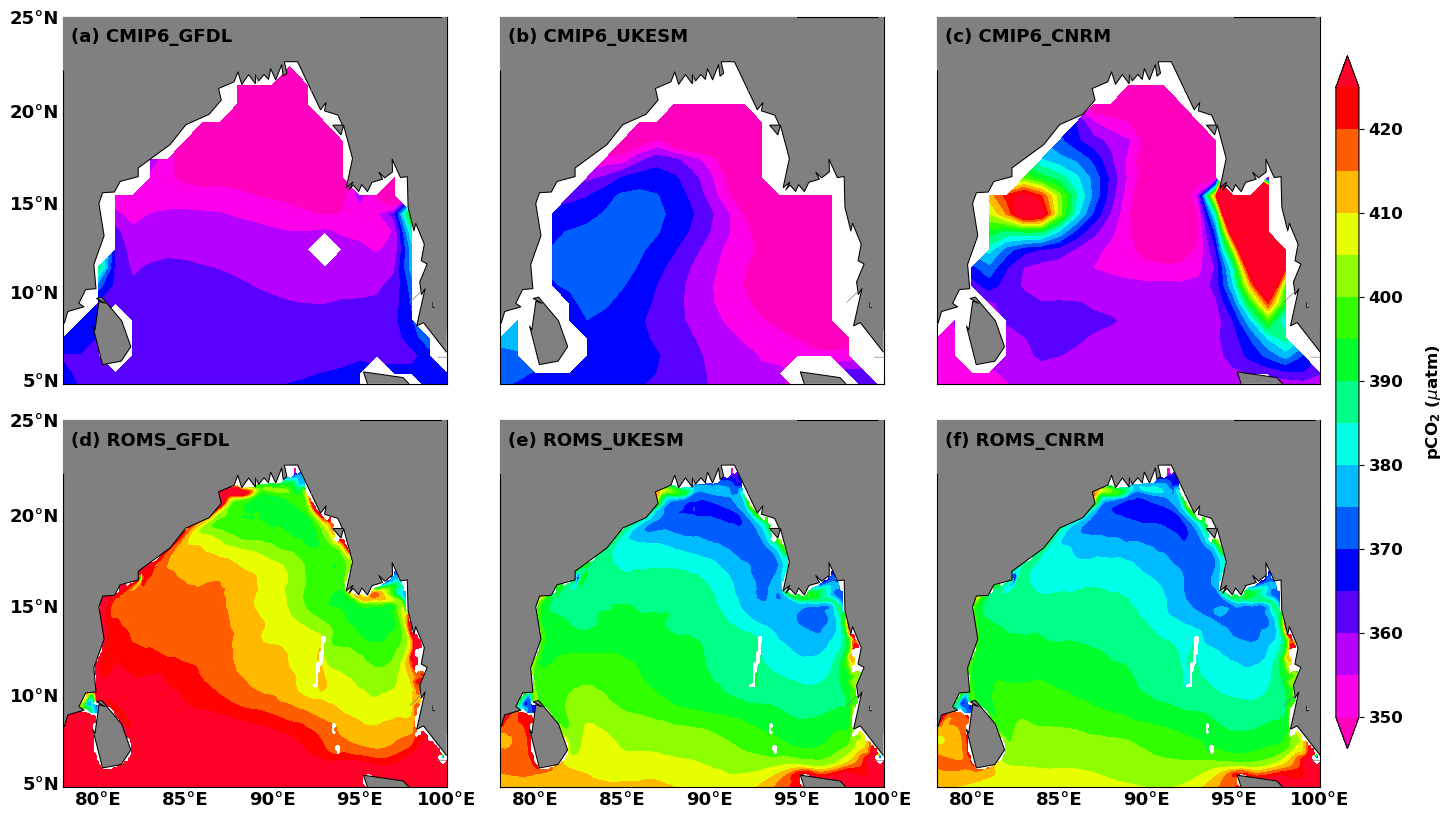

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import cmocean

def plot_map(ax, m, data, lon, lat, cmap,
             levels=None, norm=None, extend='neither',
             map_style='contour', show_lat=True, show_lon=True):

    plt.sca(ax)

    # convert to map projection coordinates
    x, y = m(lon, lat)

    # plotting
    if map_style == 'contour':
        cf = m.contourf(x, y, data,
                        levels=levels,
                        cmap=cmap,
                        norm=norm,
                        extend=extend)

    elif map_style == 'pc':
        cf = m.pcolormesh(x, y, data,
                          cmap=cmap,
                          norm=norm,
                          shading='auto')

    else:
        raise ValueError("map_style must be 'contour' or 'pc'")

    # land and coast
    m.fillcontinents(color='grey', lake_color='grey')
    m.drawcoastlines(linewidth=0.75)
    m.drawcountries(color='grey')
    m.drawstates(color='grey')

    # -------------------------------------------------
    # Mask unwanted regions
    # -------------------------------------------------
    regions = {
        'china': [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),
                  (104,0),(106.5,-7),(115,-8.5),(120,-8)],
        'victoria': [(31,-20),(35,-20),(35,1),(31,1),(31,-20)],
        'india1': [(69.5,22),(95,23),(95,28),(69.5,28),(69.5,22)],
        'india2': [(65,26),(70,26),(70,29),(65,29),(65,26)],
        'uae': [(30.5,12),(43,12),(43,29.9),(30.5,29.9),(30.5,12)],
        'uae1': [(30.5,23),(56.5,23),(56.5,29.9),(30.5,29.9),(30.5,23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[m(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)

    # -------------------------------------------------
    # Latitude lines
    # -------------------------------------------------
    if show_lat:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[1,0,0,0],
                                    fontsize=13,
                                    color='none')
    else:
        parallels = m.drawparallels(np.arange(5,26,5),
                                    labels=[0,0,0,0],
                                    fontsize=13,
                                    color='none')

    # -------------------------------------------------
    # Longitude lines
    # -------------------------------------------------
    if show_lon:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,1],
                                     fontsize=13,
                                     color='none')
    else:
        meridians = m.drawmeridians(np.arange(80,101,5),
                                     labels=[0,0,0,0],
                                     fontsize=13,
                                     color='none')

    # Bold labels
    for m1 in meridians.values():
        for t in m1[1]:
            t.set_fontweight('bold')

    for p1 in parallels.values():
        for t in p1[1]:
            t.set_fontweight('bold')

    return cf

# ---------------- FIGUR

# -----------------------------------------------------
# FIGURE LAYOUT (2 ROWS x 3 COLUMNS)
# -----------------------------------------------------
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
plt.subplots_adjust(hspace=0.1, wspace=0.02)

ax = ax.ravel()        # flatten axes → ax[0]..ax[5]


# -----------------------------------------------------
# Basemap settings
# -----------------------------------------------------
m = Basemap(
    projection='merc', resolution='c',
    llcrnrlat=4.9, urcrnrlat=25.1,
    llcrnrlon=78, urcrnrlon=100
)

# CMIP grid
lon_cmip, lat_cmip = np.meshgrid(CMIP_GF_hist.LON_RHO,
                                 CMIP_GF_hist.LAT_RHO)
# ROMS grid
lon_gfdl, lat_gfdl = np.meshgrid(GFDL_hist.LON_RHO,
                                 GFDL_hist.LAT_RHO)

# -----------------------------------------------------
# Data list (matches your requirement)
# -----------------------------------------------------
# data = [
#     CMIP_GF_hist, CMIP_UK_hist, CMIP_CN_hist,   # Row-1 (CMIP)
#     GFDL_hist,    UKESM_hist,  CNRM_hist        # Row-2 (ROMS)
# ]

# -----------------------------------------------------
# Color levels
# -----------------------------------------------------
levels_pco2 = np.arange(350, 430, 5)

cmapp = 'gist_rainbow_r' #'SpectralExtended' # 'HomeyerRainbow'
# cmapp_HP= 'ChaseSpectral'


p = plot_map(ax[0], m, CMIP_GF_hist.values, lon_cmip, lat_cmip, levels=levels_pco2, cmap=cmapp, extend='both',show_lat=True, show_lon=False)
p = plot_map(ax[1], m, CMIP_UK_hist.values, lon_cmip, lat_cmip, levels=levels_pco2, cmap=cmapp, extend='both',show_lat=False, show_lon=False)
p = plot_map(ax[2], m, CMIP_CN_hist.values, lon_cmip, lat_cmip, levels=levels_pco2, cmap=cmapp, extend='both',show_lat=False, show_lon=False)

q = plot_map(ax[3], m, GFDL_hist.values, lon_gfdl, lat_gfdl, levels=levels_pco2, cmap=cmapp, extend='both',show_lat=True, show_lon=True)
q = plot_map(ax[4], m, UKESM_hist.values, lon_gfdl, lat_gfdl, levels=levels_pco2, cmap=cmapp, extend='both',show_lat=False, show_lon=True)
q = plot_map(ax[5], m, CNRM_hist.values, lon_gfdl, lat_gfdl, levels=levels_pco2, cmap=cmapp, extend='both',show_lat=False, show_lon=True)



cb = plt.colorbar(p, ax=[ax[0],ax[2],ax[4],ax[1],ax[3],ax[5]], orientation='vertical',shrink=0.9, pad=0.01, aspect=30, extend='both')

cb.ax.set_ylabel(r"$\mathbf{pCO_{2}}$ ($\mu$atm)",fontsize=12,fontweight='bold',labelpad=15) 
cb.ax.tick_params(labelsize=12)
# make tick labels bold
for label in cb.ax.get_yticklabels():
    label.set_fontweight('bold')
                         
titles = {0: "CMIP6_GFDL", 1: "CMIP6_UKESM", 2: "CMIP6_CNRM", 
          3: "ROMS_GFDL", 4: "ROMS_UKESM", 5: "ROMS_CNRM"}

# panel label order for the used subplots
panel_labels = {0: "(a) CMIP6_GFDL", 
                1: "(b) CMIP6_UKESM", 
                2: "(c) CMIP6_CNRM",
                3: "(d) ROMS_GFDL", 
                4: "(e) ROMS_UKESM", 
                5: "(f) ROMS_CNRM"}

for idx, title in titles.items():
    # ----- panel label (top-left) -----
    ax[idx].text(
        0.02, 0.97, panel_labels[idx],
        transform=ax[idx].transAxes,
        fontsize=13, fontweight='bold',
        va='top', ha='left',zorder=100
    )

# plt.savefig('/home/incois/sridevi/pCO2_clim/CMIP_original_Downscaled.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
plt.show()

In [69]:
pCO2_ssp_585_FF=pCO2_ssp_585_FF.where(mask)
mask = pCO2_ssp_585_FF >= 1000

first_idx = mask.argmax(dim='TIME')

# Convert that index to actual time values
first_time_ROMS = pCO2_ssp_585_FF['TIME'][first_idx]

# Convert time to year
first_year_ROMS = first_time_ROMS.dt.year

# Replace locations where threshold was never reached with NaN
first_year_ROMS = first_year_ROMS.where(mask.any(dim='TIME'), np.nan)
# first_year_ROMS

In [70]:
del CMIP_GF, CMIP_CN, CMIP_UK

In [71]:
####  CMIP Original Hypercapnia
CMIP_GF = xr.open_dataset('CMIP_GFDL_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_CN1 = xr.open_dataset('CMIP_CNRM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_UK1 = xr.open_dataset('CMIP_UKESM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
# CMIP_GF,CMIP_CN,CMIP_UK,  

In [73]:
# # model have low resolution that obserrvations so, observations need to regrid
CMIP_UK = []
CMIP_UK = CMIP_UK1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)
CMIP_CN = []
CMIP_CN = CMIP_CN1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)


# print(CMIP_GF),print(CMIP_UK), print(CMIP_CN)
# CMIP_GF.dims,CMIP_UK.dims,CMIP_CN.dims


In [74]:
CMIP_CN['TIME'] = xr.cftime_range(
    start=str(CMIP_CN.TIME.values[0])[:10],
    periods=len(CMIP_CN.TIME),
    freq="MS"
)
# print(CMIP_CN.coords)
CMIP_CN = CMIP_CN.assign_coords(TIME=CMIP_GF.TIME)
CMIP_UK = CMIP_UK.assign_coords(TIME=CMIP_GF.TIME)
# print(CMIP_CN.coords)

In [75]:
CMIP_GF, CMIP_UK, CMIP_CN = xr.align(CMIP_GF, CMIP_UK, CMIP_CN)
common_mask = (~CMIP_GF.isnull()) & (~CMIP_UK.isnull()) & (~CMIP_CN.isnull())

CMIP_GF = CMIP_GF.where(common_mask)
CMIP_UK = CMIP_UK.where(common_mask)
CMIP_CN = CMIP_CN.where(common_mask)

print("GFDL NaNs:", CMIP_GF.isnull().sum().item())
print("UKESM NaNs:", CMIP_UK.isnull().sum().item())
print("CNRM NaNs:", CMIP_CN.isnull().sum().item())
CMIP_ens = xr.concat([CMIP_GF, CMIP_UK, CMIP_CN], dim='model').mean(dim='model')

GFDL NaNs: 313632
UKESM NaNs: 313632
CNRM NaNs: 313632


In [76]:
mask = CMIP_ens >= 1000

# Get index of first exceedance along TIME
first_idx = mask.argmax(dim='TIME')

# Convert index to actual time
first_time_ESM = CMIP_ens['TIME'].isel(TIME=first_idx)

# Convert time to year
first_year_ESM = first_time_ESM.dt.year

# Replace locations where threshold never occurs
first_year_ESM = first_year_ESM.where(mask.any(dim='TIME'))

# first_year_ESM

In [78]:
### ROMS down scaled Hypercapnia
import glob 
mask = xr.open_dataset('roms_mask_final.nc').mask_rho
mask

FF_list = glob.glob('*.nc')
datasets_FF = [xr.open_dataset(f) for f in FF_list]
ensemble_FF = xr.concat(datasets_FF, dim='model')
pCO2_ssp_585_FF =  ensemble_FF.mean(dim='model').pCO2
print(len(FF_list))
print(FF_list)
pCO2_ssp_585_FF=pCO2_ssp_585_FF.where(mask)
mask = pCO2_ssp_585_FF >= 1000

3
['/home/incois/prasanna/ROMS_Projection/Codes/MF_FF_pH_HPlus/Interannual/pCO2/FF/ROMS_GFDL_FF_pCO2_surface.nc', '/home/incois/prasanna/ROMS_Projection/Codes/MF_FF_pH_HPlus/Interannual/pCO2/FF/ROMS_CNRM_FF_pCO2_surface.nc', '/home/incois/prasanna/ROMS_Projection/Codes/MF_FF_pH_HPlus/Interannual/pCO2/FF/ROMS_UKESM_FF_pCO2_surface.nc']


In [79]:
pCO2_ssp_585_FF=pCO2_ssp_585_FF.where(mask)
mask = pCO2_ssp_585_FF >= 1000

first_idx = mask.argmax(dim='TIME')

# Convert that index to actual time values
first_time_ROMS = pCO2_ssp_585_FF['TIME'][first_idx]

# Convert time to year
first_year_ROMS = first_time_ROMS.dt.year

# Replace locations where threshold was never reached with NaN
first_year_ROMS = first_year_ROMS.where(mask.any(dim='TIME'), np.nan)
# first_year_ROMS

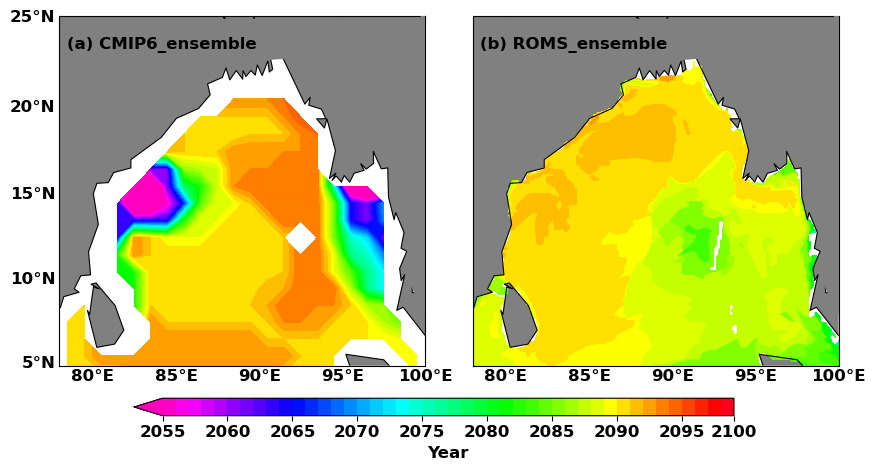

In [80]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np

fig, ax = plt.subplots(1,2, figsize=(12,5))


plt.rcParams.update({
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

levels_diff_pCO2 = np.arange(2055,2100,1)
cmapp = 'gist_rainbow_r'

# ---------- subplot 1 ----------
map1 = Basemap(projection='merc', resolution='c',
               llcrnrlat=4.9, urcrnrlat=25.1,
               llcrnrlon=78, urcrnrlon=100,
               ax=ax[0])

map1.drawcoastlines(linewidth=0.8)
map1.fillcontinents(color='grey', lake_color='grey')

map1.drawparallels(np.arange(5,26,5), labels=[1,0,0,0], fontsize=12, linewidth=0.001)
map1.drawmeridians(np.arange(80,100.1,5), labels=[0,0,0,1], fontsize=12, linewidth=0.001)


regions = {
    'china': [(106,-5),(120,-8.5),(120,29.5),(100,29.5),(99,10),
              (104,0),(106.5,-7),(115,-8.5),(120,-8)],

    'india1': [(80,22),(95,23),(95,24.9),(80,24.9),(80,22)],
    # 'india2': [(65,25),(70,25),(70,25),(65,25),(65,24.9)],
    # 'uae': [(30.5,12),(43,12),(43,29.9),(30.5,29.9),(30.5,12)],
    # 'uae1': [(30.5,23),(56.5,23),(56.5,29.9),(30.5,29.9),(30.5,23)]
}

for coords in regions.values():
    x_r, y_r = zip(*[map1(lon, lat) for lon, lat in coords])
    ax[0].fill(x_r, y_r, color='grey', zorder=5)


    
    
lon1, lat1 = np.meshgrid(first_year_ESM.LON_RHO, first_year_ESM.LAT_RHO)
lon1, lat1 = map1(lon1, lat1)

p1 = map1.contourf(lon1, lat1, first_year_ESM,
                   levels=levels_diff_pCO2,
                   cmap=cmapp,
                   extend='min')

ax[0].text(0.02, 0.94, '(a) CMIP6_ensemble', transform=ax[0].transAxes, fontsize=12, fontweight='bold', ha='left', va='top',zorder=100)

# ---------- subplot 2 ----------
map2 = Basemap(projection='merc', resolution='c',
               llcrnrlat=4.9, urcrnrlat=25.1,
               llcrnrlon=78, urcrnrlon=100,
               ax=ax[1])

map2.drawcoastlines(linewidth=0.8)
map2.fillcontinents(color='grey', lake_color='grey')

map2.drawparallels(np.arange(5,26,5), labels=[0,0,0,0], fontsize=12, linewidth=0.001)
map2.drawmeridians(np.arange(80,100.1,5), labels=[0,0,0,1], fontsize=12, linewidth=0.001)

for coords in regions.values():
    x_r, y_r = zip(*[map2(lon, lat) for lon, lat in coords])
    ax[1].fill(x_r, y_r, color='grey', zorder=5)


lon2, lat2 = np.meshgrid(first_year_ROMS.LON_RHO, first_year_ROMS.LAT_RHO)
lon2, lat2 = map2(lon2, lat2)

p2 = map2.contourf(lon2, lat2, first_year_ROMS,
                   levels=levels_diff_pCO2,
                   cmap=cmapp,
                   extend='min')

# ax[1].set_title('ensemble', fontweight='bold')
ax[1].text(0.02, 0.94, '(b) ROMS_ensemble', transform=ax[1].transAxes, fontsize=12, fontweight='bold', ha='left', va='top',zorder=100)


# ---------- spacing ----------
plt.subplots_adjust(wspace=-0.2, hspace=0.05, bottom=0.18)

# ---------- colorbar axis ----------
cax = fig.add_axes([0.25, 0.08, 0.5, 0.035])  # [left, bottom, width, height]

cb = fig.colorbar(p2,
                  cax=cax,
                  orientation='horizontal',
                  ticks=np.arange(2055,2102,5))

cb.set_label('Year', fontsize=12, fontweight='bold')

# plt.savefig('CMIP_downscaled_hypercapnia_BoB.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
plt.show()

# pCO2 uncertanity in CMIP downscaled

In [81]:
from scipy.stats import linregress
def reg_line(a):
    slope, intercept, rvalue, pvalue, stderr = linregress(np.arange(1,len(a)+1),a)
    reg=slope*np.arange(1,len(a)+1)+intercept
    return reg,slope,pvalue,stderr

def calculate_slope(data_array):
    slopes = np.apply_along_axis(lambda y: linregress(range(len(y)), y).slope*12, axis=0, arr=data_array)
    return slopes


def calculate_pval(data_array):
    pvals = np.apply_along_axis(lambda y: linregress(range(len(y)), y).pvalue, axis=0, arr=data_array)
    return pvals

def calculate_intercept(data_array):
    pvals = np.apply_along_axis(lambda y: linregress(range(len(y)), y).intercept, axis=0, arr=data_array)
    return pvals

In [82]:
def plot_map(ax, map, data, lon, lat, cmap,levels=None, norm=None,extend='neither',map_style=None,grid=False):
    if map_style=='contour':
        cf = map.contourf(lon, lat, data, levels=levels, norm=norm,cmap=cmap, extend=extend, ax=ax,robust=True)
    elif  map_style=='pc':
        cf = map.pcolormesh(lon,lat,data,norm=norm, cmap=cmap,shading='gouraud',edgecolors ='face',ax=ax)
    else:
        print('Not possible')
    map.fillcontinents(color='grey', lake_color='grey', ax=ax)
    map.drawcoastlines(ax=ax, linewidth=0.75)
    map.drawcountries(color='grey', ax=ax)
    map.drawstates(color='grey', ax=ax)
    map.drawmeridians(np.arange(40, 120, 5), labels=[0, 0, 0, 1], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
    map.drawparallels(np.arange(-30, 31, 5), labels=[1, 0, 0, 0], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
    regions = {
        'china': [(106, -5), (120, -8.5), (120, 29.5), (100, 29.5), (99, 10),
                  (104, 0), (106.5, -7), (115, -8.5), (120, -8)],
        'victoria': [(31, -20), (35, -20), (35, 1), (31, 1), (31, -20)],
        'india1': [(69.5, 22), (95, 23), (95, 28), (69.5, 28), (69.5, 22)],
        'india2': [(65, 26), (70, 26), (70, 29), (65, 29), (65, 26)],
        'uae': [(30.5, 12), (43, 12), (43, 29.9), (30.5, 29.9), (30.5, 12)],
        'uae1': [(30.5, 23), (56.5, 23), (56.5, 29.9), (30.5, 29.9), (30.5, 23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[map(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)
    return cf

In [83]:
mask_for_roms = xr.open_dataset('/home/incois/prasanna/ROMS_Projection/Codes/roms_mask_final.nc').mask_rho.squeeze()

def ensem(d1,d2,d3):
    combined = xr.concat([d1, d2, d3], dim='member')
    std_result = combined.std(dim='member')
    return (d1+d2+d3)/3,std_result

In [84]:
GFDL_pCO2_NF = xr.open_dataset('ROMS_GFDL_HIS_NF_pCO2_corrected.nc').pCO2.sel(TIME=slice('2015','2040')).where(mask_for_roms)
CNRM_pCO2_NF = xr.open_dataset('ROMS_CNRM_HIS_NF_pCO2_corrected.nc').pCO2.sel(TIME=slice('2015','2040')).where(mask_for_roms)
UKESM_pCO2_NF = xr.open_dataset('ROMS_UKESM_HIS_NF_pCO2_corrected.nc').pCO2.sel(TIME=slice('2015','2040')).where(mask_for_roms)

GFDL_pCO2_MF = xr.open_dataset('ROMS_GFDL_MF_pCO2_surface.nc').pCO2.sel(TIME=slice('2041','2070')).where(mask_for_roms)
CNRM_pCO2_MF = xr.open_dataset('ROMS_CNRM_MF_pCO2_surface.nc').pCO2.sel(TIME=slice('2041','2070')).where(mask_for_roms)
UKESM_pCO2_MF = xr.open_dataset('ROMS_UKESM_MF_pCO2_surface.nc').pCO2.sel(TIME=slice('2041','2070')).where(mask_for_roms)

GFDL_pCO2_FF = xr.open_dataset('ROMS_GFDL_FF_pCO2_surface.nc').pCO2.sel(TIME=slice('2071','2100')).where(mask_for_roms)
CNRM_pCO2_FF = xr.open_dataset('ROMS_CNRM_FF_pCO2_surface.nc').pCO2.sel(TIME=slice('2071','2100')).where(mask_for_roms)
UKESM_pCO2_FF = xr.open_dataset('ROMS_UKESM_FF_pCO2_surface.nc').pCO2.sel(TIME=slice('2071','2100')).where(mask_for_roms)

GFDL_pCO2_hist = xr.open_dataset('ROMS_GFDL_HIS_NF_pCO2_corrected.nc').pCO2.sel(TIME=slice('1980','2014')).where(mask_for_roms)
CNRM_pCO2_hist = xr.open_dataset('ROMS_CNRM_HIS_NF_pCO2_corrected.nc').pCO2.sel(TIME=slice('1980','2014')).where(mask_for_roms)
UKESM_pCO2_hist = xr.open_dataset('ROMS_UKESM_HIS_NF_pCO2_corrected.nc').pCO2.sel(TIME=slice('1980','2014')).where(mask_for_roms)
# CNRM_pCO2_MF

In [85]:
Hist_pCO2 = ensem(GFDL_pCO2_hist,CNRM_pCO2_hist,UKESM_pCO2_hist)
Final_NF_pCO2 = ensem(GFDL_pCO2_NF,CNRM_pCO2_NF,UKESM_pCO2_NF)
Final_MF_pCO2 = ensem(GFDL_pCO2_MF,CNRM_pCO2_MF,UKESM_pCO2_MF)
Final_FF_pCO2 = ensem(GFDL_pCO2_FF,CNRM_pCO2_FF,UKESM_pCO2_FF)

In [86]:
from mpl_toolkits.basemap import Basemap
# Hist_pCO2[1], Final_Fut_pCO2[1]
hispco2 = Hist_pCO2[1].mean(dim='TIME')
hispco2
# finpco2 = Final_Fut_pCO2[1].mean(dim='TIME')
# finpco2

nfpco2 = Final_NF_pCO2[1].mean(dim='TIME')
mfpco2 = Final_MF_pCO2[1].mean(dim='TIME')
ffpco2 = Final_FF_pCO2[1].mean(dim='TIME')

In [87]:
def plot_map(ax, map, data, lon, lat, cmap,levels=None, norm=None,extend='neither',map_style=None,show_lat=True, show_lon=True):
    if map_style=='contour':
        cf = map.contourf(lon, lat, data, levels=levels, norm=norm,cmap=cmap, extend=extend, ax=ax)
    elif  map_style=='pc':
        cf = map.pcolormesh(lon,lat,data,norm=norm, cmap=cmap,shading='gouraud',edgecolors ='face',ax=ax)
    else:
        print('Not possible')
    map.fillcontinents(color='grey', lake_color='grey', ax=ax)
    map.drawcoastlines(ax=ax, linewidth=0.75)
    map.drawcountries(color='grey', ax=ax)
    map.drawstates(color='grey', ax=ax)
#     map.drawmeridians(np.arange(40, 120, 5), labels=[0, 0, 0, 1], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
#     map.drawparallels(np.arange(-30, 31, 5), labels=[1, 0, 0, 0], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
    regions = {
        'china': [(106, -5), (120, -8.5), (120, 29.5), (100, 29.5), (99, 10),
                  (104, 0), (106.5, -7), (115, -8.5), (120, -8)],
        'victoria': [(31, -20), (35, -20), (35, 1), (31, 1), (31, -20)],
        'india1': [(69.5, 22), (95, 23), (95, 28), (69.5, 28), (69.5, 22)],
        'india2': [(65, 26), (70, 26), (70, 29), (65, 29), (65, 26)],
        'uae': [(30.5, 12), (43, 12), (43, 29.9), (30.5, 29.9), (30.5, 12)],
        'uae1': [(30.5, 23), (56.5, 23), (56.5, 29.9), (30.5, 29.9), (30.5, 23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[map(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)
        
        
    if show_lat:
        paralles = map.drawparallels(np.arange(5,26,5),
                              labels=[1,0,0,0],
                              fontsize=12,
                              color='none',
                              ax=ax)
    else:
        paralles = map.drawparallels(np.arange(5,26,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)

    # Longitude labels
    if show_lon:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,1],
                          fontsize=12,
                          color='none',
                          ax=ax)
    else:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)
    # Make labels bold
    for m in meridians.values():
        for t in m[1]:
            t.set_fontweight('bold')

    for p in paralles.values():
        for t in p[1]:
            t.set_fontweight('bold')
   
    return cf

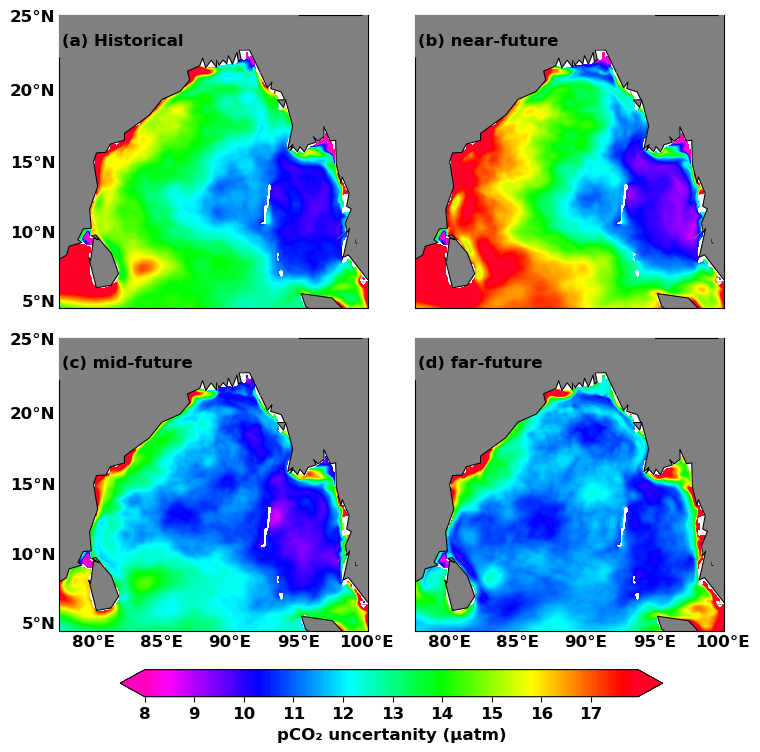

In [88]:
# Individual periods uncertanity

fig,ax=plt.subplots(2,2,figsize=(10,10))
ax=ax.ravel()
plt.rcParams.update({
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

plt.subplots_adjust(wspace=-0.15,hspace=0.1)

ax = ax.ravel()

map = Basemap(projection='merc', resolution='c',
              llcrnrlat=4.5, urcrnrlat=25.1,
              llcrnrlon=77.5, urcrnrlon=100.1)

masked_lon, masked_lat = np.meshgrid(Hist_pCO2[1].LON_RHO, Hist_pCO2[1].LAT_RHO)
lon, lat = map(masked_lon, masked_lat)

levels_diff_pH = np.arange(8,18,0.05)


# cmapp= 'ChaseSpectral'
cmapp_HP= 'gist_rainbow_r'

p = plot_map(ax[0], map, hispco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=True,show_lon=False)
q = plot_map(ax[1], map, nfpco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=False,show_lon=False)
r = plot_map(ax[2], map, mfpco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=True,show_lon=True)
s = plot_map(ax[3], map, ffpco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=False,show_lon=True)


cb = plt.colorbar(p, ax=[ax[0],ax[1],ax[2],ax[3]], orientation='horizontal',shrink=0.7, pad=0.05, aspect=20, extend='both')
cb.set_label('pCO₂ uncertanity (µatm)', fontsize=12, fontweight = 'bold')

labels = ['Historical', 'near-future', 'mid-future', 'far-future']


for i in range(4):
    text = f"({chr(97 + i)}) {labels[i]}"
    
    ax[i].text(0.01, 0.94, text,
               transform=ax[i].transAxes,
               fontsize=12, fontweight='bold',
               va='top', ha='left',zorder=100)
    
# plt.savefig('pCO2_Uncertainty_all_periods.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
plt.show()

# pCO2 uncertanity in CMIP orginal

In [89]:
### needs to update data files here for Future Downscaled influence to understand  .sel(LON_RHO=slice(30,119.5),LAT_RHO=slice(-31,31)) 
CMIP_GF = xr.open_dataset('CMIP_GFDL_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_CN1 = xr.open_dataset('CMIP_CNRM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_UK1 = xr.open_dataset('CMIP_UKESM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
# CMIP_GF,CMIP_CN,CMIP_UK,  

In [90]:
# # model have low resolution that obserrvations so, observations need to regrid
CMIP_UK = []
CMIP_UK = CMIP_UK1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)
CMIP_CN = []
CMIP_CN = CMIP_CN1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)


# print(CMIP_GF),print(CMIP_UK), print(CMIP_CN)
# CMIP_GF.dims,CMIP_UK.dims,CMIP_CN.dims


In [91]:
CMIP_CN['TIME'] = xr.cftime_range(
    start=str(CMIP_CN.TIME.values[0])[:10],
    periods=len(CMIP_CN.TIME),
    freq="MS"
)
print(CMIP_CN.coords)
CMIP_CN = CMIP_CN.assign_coords(TIME=CMIP_GF.TIME)
CMIP_UK = CMIP_UK.assign_coords(TIME=CMIP_GF.TIME)
print(CMIP_CN.coords)

Coordinates:
  * LON_RHO  (LON_RHO) float64 176B 78.5 79.5 80.5 81.5 ... 96.5 97.5 98.5 99.5
  * LAT_RHO  (LAT_RHO) float64 168B 4.5 5.5 6.5 7.5 8.5 ... 21.5 22.5 23.5 24.5
  * TIME     (TIME) object 12kB 1980-02-01 00:00:00 ... 2101-01-01 00:00:00
Coordinates:
  * LON_RHO  (LON_RHO) float64 176B 78.5 79.5 80.5 81.5 ... 96.5 97.5 98.5 99.5
  * LAT_RHO  (LAT_RHO) float64 168B 4.5 5.5 6.5 7.5 8.5 ... 21.5 22.5 23.5 24.5
  * TIME     (TIME) object 12kB 1980-01-16 12:00:00 ... 2100-12-16 12:00:00


In [92]:
import xarray as xr

CMIP_GF, CMIP_UK, CMIP_CN = xr.align(CMIP_GF, CMIP_UK, CMIP_CN)
common_mask = (~CMIP_GF.isnull()) & (~CMIP_UK.isnull()) & (~CMIP_CN.isnull())

CMIP_GF = CMIP_GF.where(common_mask)
CMIP_UK = CMIP_UK.where(common_mask)
CMIP_CN = CMIP_CN.where(common_mask)

print("GFDL NaNs:", CMIP_GF.isnull().sum().item())
print("UKESM NaNs:", CMIP_UK.isnull().sum().item())
print("CNRM NaNs:", CMIP_CN.isnull().sum().item())

GFDL NaNs: 313632
UKESM NaNs: 313632
CNRM NaNs: 313632


In [93]:
def ensem(d1,d2,d3):
    combined = xr.concat([d1, d2, d3], dim='member')
    std_result = combined.std(dim='member')
    return (d1+d2+d3)/3,std_result

In [94]:
CMIP_GF_hs = CMIP_GF.sel(TIME=slice('1980','2014'))
CMIP_UK_hs = CMIP_UK.sel(TIME=slice('1980','2014'))
CMIP_CN_hs = CMIP_CN.sel(TIME=slice('1980','2014'))
Hist_CMIP = ensem(CMIP_GF_hs,CMIP_CN_hs,CMIP_UK_hs)
Hist_CMIP[1]

CMIP_GF_nf = CMIP_GF.sel(TIME=slice('2015','2040'))
CMIP_UK_nf = CMIP_UK.sel(TIME=slice('2015','2040'))
CMIP_CN_nf = CMIP_CN.sel(TIME=slice('2015','2040'))
nf_CMIP = ensem(CMIP_GF_nf,CMIP_CN_nf,CMIP_UK_nf)

CMIP_GF_mf = CMIP_GF.sel(TIME=slice('2041','2070'))
CMIP_UK_mf = CMIP_UK.sel(TIME=slice('2041','2070'))
CMIP_CN_mf = CMIP_CN.sel(TIME=slice('2041','2070'))
mf_CMIP = ensem(CMIP_GF_mf,CMIP_CN_mf,CMIP_UK_mf)
 
CMIP_GF_ff = CMIP_GF.sel(TIME=slice('2071','2100'))
CMIP_UK_ff = CMIP_UK.sel(TIME=slice('2071','2100'))
CMIP_CN_ff = CMIP_CN.sel(TIME=slice('2071','2100'))
ff_CMIP = ensem(CMIP_GF_ff,CMIP_CN_ff,CMIP_UK_ff)
# ff_CMIP[1]

In [95]:
from mpl_toolkits.basemap import Basemap
# Hist_pCO2[1], Final_Fut_pCO2[1]
CMIP_hispco2 = Hist_CMIP[1].mean(dim='TIME')
CMIP_hispco2
# finpco2 = Final_Fut_pCO2[1].mean(dim='TIME')
# finpco2

CMIP_nfpco2 = nf_CMIP[1].mean(dim='TIME')
CMIP_mfpco2 = mf_CMIP[1].mean(dim='TIME')
CMIP_ffpco2 = ff_CMIP[1].mean(dim='TIME')
# CMIP_ffpco2

In [96]:
def plot_map(ax, map, data, lon, lat, cmap,levels=None, norm=None,extend='neither',map_style=None,show_lat=True, show_lon=True):
    if map_style=='contour':
        cf = map.contourf(lon, lat, data, levels=levels, norm=norm,cmap=cmap, extend=extend, ax=ax)
    elif  map_style=='pc':
        cf = map.pcolormesh(lon,lat,data,norm=norm, cmap=cmap,shading='gouraud',edgecolors ='face',ax=ax)
    else:
        print('Not possible')
    map.fillcontinents(color='grey', lake_color='grey', ax=ax)
    map.drawcoastlines(ax=ax, linewidth=0.75)
    map.drawcountries(color='grey', ax=ax)
    map.drawstates(color='grey', ax=ax)
#     map.drawmeridians(np.arange(40, 120, 5), labels=[0, 0, 0, 1], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
#     map.drawparallels(np.arange(-30, 31, 5), labels=[1, 0, 0, 0], color='white', fontsize=10, fontweight='bold', ax=ax, zorder=0)
    regions = {
        'china': [(106, -5), (120, -8.5), (120, 29.5), (100, 29.5), (99, 10),
                  (104, 0), (106.5, -7), (115, -8.5), (120, -8)],
        'victoria': [(31, -20), (35, -20), (35, 1), (31, 1), (31, -20)],
        'india1': [(69.5, 22), (95, 23), (95, 28), (69.5, 28), (69.5, 22)],
        'india2': [(65, 26), (70, 26), (70, 29), (65, 29), (65, 26)],
        'uae': [(30.5, 12), (43, 12), (43, 29.9), (30.5, 29.9), (30.5, 12)],
        'uae1': [(30.5, 23), (56.5, 23), (56.5, 29.9), (30.5, 29.9), (30.5, 23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[map(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)
        
        
    if show_lat:
        paralles = map.drawparallels(np.arange(5,26,5),
                              labels=[1,0,0,0],
                              fontsize=12,
                              color='none',
                              ax=ax)
    else:
        paralles = map.drawparallels(np.arange(5,26,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)

    # Longitude labels
    if show_lon:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,1],
                          fontsize=12,
                          color='none',
                          ax=ax)
    else:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)
    # Make labels bold
    for m in meridians.values():
        for t in m[1]:
            t.set_fontweight('bold')

    for p in paralles.values():
        for t in p[1]:
            t.set_fontweight('bold')
   
    return cf

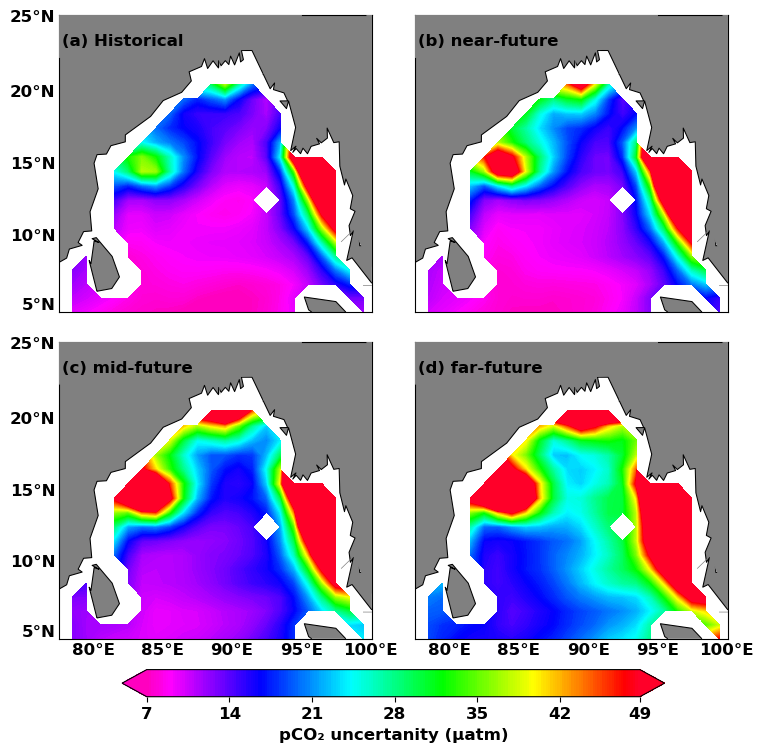

In [97]:
# Individual periods uncertanity

fig,ax=plt.subplots(2,2,figsize=(10,10))
ax=ax.ravel()
plt.rcParams.update({
    "font.size": 12,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})
plt.subplots_adjust(wspace=-0.15,hspace=0.1)

ax = ax.ravel()

map = Basemap(projection='merc', resolution='c',
              llcrnrlat=4.5, urcrnrlat=25.1,
              llcrnrlon=77.5, urcrnrlon=100.1)

masked_lon, masked_lat = np.meshgrid(Hist_CMIP[1].LON_RHO, Hist_CMIP[1].LAT_RHO)
lon, lat = map(masked_lon, masked_lat)

levels_diff_pH = np.arange(7,49,0.2)


# cmapp= 'ChaseSpectral'
cmapp_HP= 'gist_rainbow_r'

p = plot_map(ax[0], map, CMIP_hispco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=True,show_lon=False)
q = plot_map(ax[1], map, CMIP_nfpco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=False,show_lon=False)
r = plot_map(ax[2], map, CMIP_mfpco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=True,show_lon=True)
s = plot_map(ax[3], map, CMIP_ffpco2, lon, lat,levels=levels_diff_pH,  cmap=cmapp_HP, extend='both',map_style='contour',show_lat=False,show_lon=True)

cb = plt.colorbar(p, ax=[ax[0],ax[1],ax[2],ax[3]], orientation='horizontal',shrink=0.7, pad=0.04, aspect=20, ticks=[7, 14, 21, 28, 35, 42, 49], extend='both')
cb.set_label('pCO₂ uncertanity (µatm)', fontsize=12, fontweight = 'bold')

labels = ['Historical', 'near-future', 'mid-future', 'far-future']



for i in range(4):
    text = f"({chr(97 + i)}) {labels[i]}"
    
    ax[i].text(0.01, 0.94, text,
               transform=ax[i].transAxes,
               fontsize=12, fontweight='bold',
               va='top', ha='left',zorder=100)
    
# plt.savefig('CMIP_pCO2_Uncertainty_all_periods.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         
plt.show()

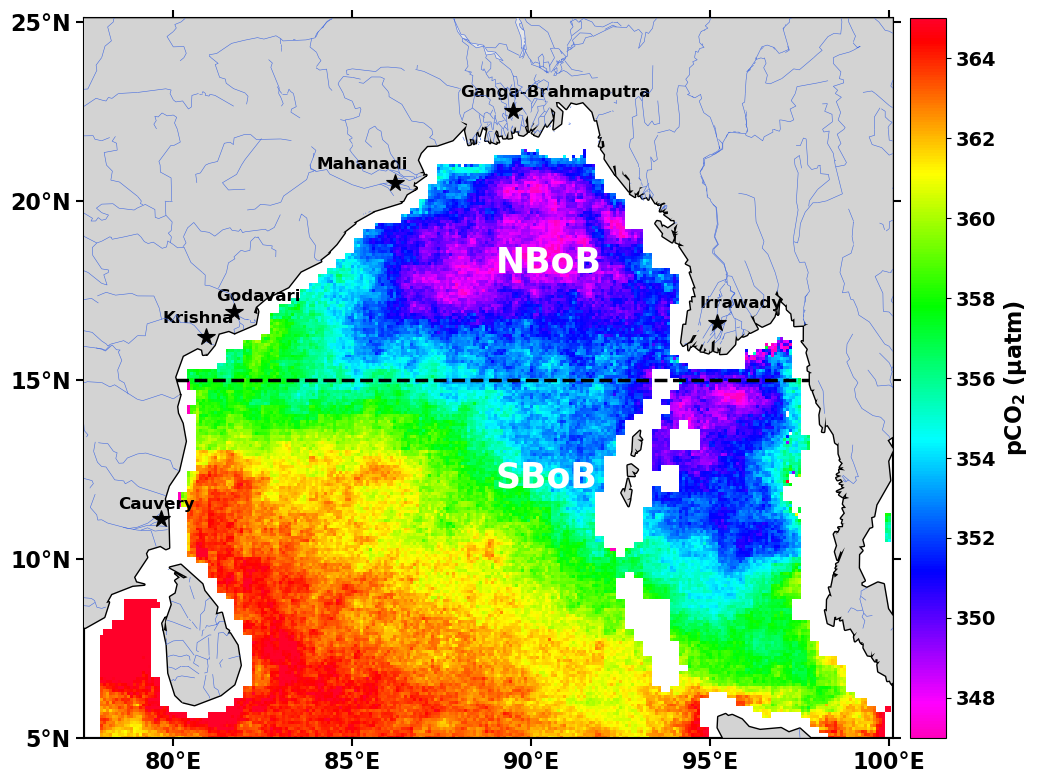

In [98]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

# -----------------------------
# Load data
# -----------------------------
ds2 = xr.open_dataset('XGBoost_BoB_pCO2_V3.nc',decode_times=False)

obs1 = ds2.sel(
    Lon=slice(78,100),
    Lat=slice(4.9,25.1)
)

# correction
obs1 = obs1 - 27

# annual mean
pco2_mean = obs1.pCO2.mean(dim='Time')

lon = obs1.Lon.values
lat = obs1.Lat.values

lon2d, lat2d = np.meshgrid(lon, lat)

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(12,8))

# -----------------------------
# Basemap
# -----------------------------
m = Basemap(
projection='cyl',
llcrnrlon=77.5,
urcrnrlon=100.1,
llcrnrlat=5,
urcrnrlat=25.1,
resolution='l',
ax=ax
)

# -----------------------------
# pCO2 spatial map
# -----------------------------
x, y = m(lon2d, lat2d)

cs = m.pcolormesh(
x,
y,
pco2_mean,
cmap='gist_rainbow_r',
shading='auto',
vmin=347,
vmax=365
)

# -----------------------------
# Land + coastlines
# -----------------------------
m.fillcontinents(color='lightgray', lake_color='0.9', zorder=3)
m.drawcoastlines(linewidth=2)

# -----------------------------
# Rivers
# -----------------------------
m.drawrivers(color='royalblue', linewidth=0.4, zorder=4)

# -----------------------------
# Map boundary
# -----------------------------
m.drawmapboundary(linewidth=1.5)

# -----------------------------
# 15°N dashed line
# -----------------------------
lon_line = np.linspace(78,100,5)
lat_line = np.full_like(lon_line,15)

x1, y1 = m(lon_line, lat_line)
m.plot(x1,y1,color='black',linewidth=2.5,linestyle='dashed',)

# -----------------------------
# NBoB box
# -----------------------------
# lon_box = [78,100,100,78,78]
# lat_box = [15,15,23.5,23.5,15]

# xbox, ybox = m(lon_box, lat_box)
# m.plot(xbox,ybox,color='black',linewidth=2)

# -----------------------------
# SBoB box
# -----------------------------
# lon_box2 = [78,100,100,78,78]
# lat_box2 = [5,5,15,15,5]

# xbox2, ybox2 = m(lon_box2, lat_box2)
# m.plot(xbox2,ybox2,color='black',linewidth=2)

# -----------------------------
# Labels
# -----------------------------
plt.text(89,18,'NBoB',fontsize=25,fontweight='bold',color='white')
plt.text(89,12,'SBoB',fontsize=25,fontweight='bold',color='white')
plt.text(88,22.9, 'Ganga-Brahmaputra', fontsize=12,fontweight='bold')
plt.text(81.2,17.2, 'Godavari', fontsize=12,fontweight='bold')
plt.text(79.7,16.6, 'Krishna', fontsize=12,fontweight='bold')
plt.text(84,20.9, 'Mahanadi', fontsize=12,fontweight='bold')
plt.text(78.45,11.4, 'Cauvery', fontsize=12,fontweight='bold')
plt.text(94.7,17, 'Irrawady', fontsize=12,fontweight='bold')

# -----------------------------
# River mouth markers
# -----------------------------

river_points = {
"Ganga-Brahmaputra": (89.5, 22.5),
"Mahanadi": (86.2, 20.5),
"Godavari": (81.7, 16.9),
"Krishna": (80.9, 16.2),
"Cauvery": (79.65, 11.1),
"Irrawady": (95.2, 16.6)
}

for name, (lon_r, lat_r) in river_points.items():
    xr, yr = m(lon_r, lat_r)

    m.plot(
        xr, yr,
        marker='*',        # star marker
        markersize=13,
        color='black',
        markeredgecolor='black',
        markeredgewidth=0.8,
        zorder=6
    )


# # -----------------------------
# Longitude ticks
# -----------------------------
xticks = range(80,101,5)
plt.xticks(
xticks,
[f"{x}°E" for x in xticks],
fontsize=16,
fontweight='bold'
)

# -----------------------------
# Latitude ticks
# -----------------------------
yticks = range(5,26,5)
plt.yticks(
yticks,
[f"{y}°N" for y in yticks],
fontsize=16,
fontweight='bold'
)

# -----------------------------
# Tick style
# -----------------------------
ax.tick_params(
axis='both',
which='both',
direction='out',
top=True,
bottom=True,
left=True,
right=True,
length=6,
width=1.5
)

# -----------------------------
# Colorbar
# -----------------------------
cbar = plt.colorbar(cs,pad=0.015)
cbar.set_label(r'pCO$_{\mathbf{2}}$ (µatm)', fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=14)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
# -----------------------------
# Layout
# -----------------------------
plt.tight_layout()

# plt.savefig('study_region.png',dpi=600)


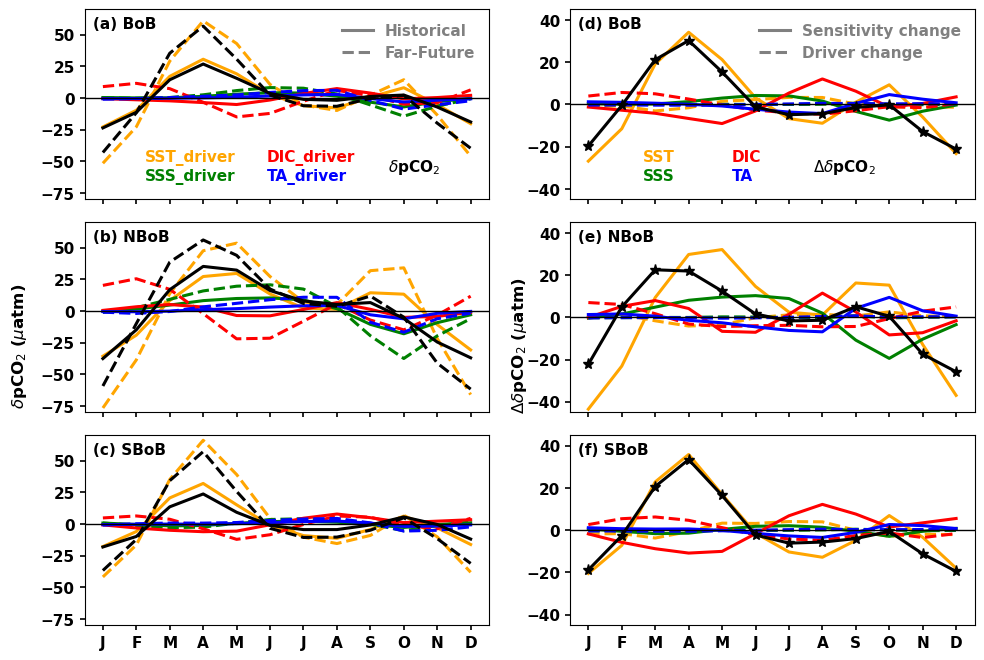

In [99]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1. OPEN THE TWO NETCDF FILES
# ============================================================

sea_driv = xr.open_dataset("Seasonal_drivers_HS_FF_final.nc")
sea_amp = xr.open_dataset("Seasonal_amplification_HS_FF_final.nc")

# ============================================================
# 2. SETTINGS
# ============================================================

regions = ["BoB", "NBoB", "SBoB"]

left_titles = [
    "(a) BoB",
    "(b) NBoB",
    "(c) SBoB"
]

right_titles = [
    "(d) BoB",
    "(e) NBoB",
    "(f) SBoB"
]

months = np.arange(1, 13)

month_labels = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
# month_labels = [
#     "Jan", "Feb", "Mar", "Apr", "May", "Jun",
#     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
# ]

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

colors = {
    "SST": "orange",
    "SSS": "green",
    "DIC": "red",
    "TA": "blue",
    "pCO2": "black"
}

# ============================================================
# 3. MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

# ============================================================
# 4. CREATE 3 × 2 FIGURE
# ============================================================

fig, axs = plt.subplots(
    3, 2,
    figsize=(10, 7),
    sharex="col"
)

# ============================================================
# 5. LEFT COLUMN
#    Historical = solid
#    Far-Future = dashed
# ============================================================

parameters_left = ["SST", "SSS", "DIC", "TA", "δpCO₂"]

for i, (region, title) in enumerate(zip(regions, left_titles)):

    ax = axs[i, 0]

    for parameter in parameters_left:

        # ----------------------------------------------------
        # Historical
        # ----------------------------------------------------
        hist = sea_driv["delta_pCO2_driver"].sel(
            period="Historical",
            region=region,
            parameter=parameter
        ).values

        # ----------------------------------------------------
        # Far-Future
        # ----------------------------------------------------
        future = sea_driv["delta_pCO2_driver"].sel(
            period="Far-Future",
            region=region,
            parameter=parameter
        ).values

        # ----------------------------------------------------
        # Historical = solid
        # ----------------------------------------------------
        ax.plot(
            months,
            hist,
            color=colors[parameter if parameter != "δpCO₂" else "pCO2"],
            lw=2.2,
            ls="-"
        )

        # ----------------------------------------------------
        # Far-Future = dashed
        # ----------------------------------------------------
        ax.plot(
            months,
            future,
            color=colors[parameter if parameter != "δpCO₂" else "pCO2"],
            lw=2.2,
            ls="--"
        )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1
    )

    # Panel label
    ax.text(
        0.02,
        0.90,
        title,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Y-axis range
    # --------------------------------------------------------
    ax.set_ylim(-80, 70)
    ax.set_yticks([-75, -50, -25, 0, 25, 50])

    # Tick properties
    ax.tick_params(
        width=1.2,
        labelsize=11
    )

    # Hide x labels except bottom
    if i < 2:
        ax.tick_params(labelbottom=False)

# ============================================================
# 6. LEFT PANEL ANNOTATIONS
# ============================================================

ax = axs[0, 0]

ax.text(
    0.15, 0.20,
    "SST_driver",
    color="orange",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.15, 0.10,
    "SSS_driver",
    color="green",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.45, 0.20,
    "DIC_driver",
    color="red",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.45, 0.10,
    "TA_driver",
    color="blue",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.75, 0.15,
    r"$\delta$pCO$_2$",
    color="black",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

# ============================================================
# 7. HISTORICAL / FAR-FUTURE LEGEND
# ============================================================

style_legend = [
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="-",
        label="Historical"
    ),
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="--",
        label="Far-Future"
    )
]

axs[0, 0].legend(
    handles=style_legend,
    loc="upper right",
    fontsize=11,
    framealpha=0,
    labelcolor="gray"
)

# ============================================================
# 8. RIGHT COLUMN
#
# Solid  = Sensitivity change
# Dashed = Driver change
# Black stars = ΔδpCO2
# ============================================================

for i, (region, title) in enumerate(zip(regions, right_titles)):

    ax = axs[i, 1]

    # --------------------------------------------------------
    # SST
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_sst"].sel(region=region).values,
        color="orange",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_sst"].sel(region=region).values,
        color="orange",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # SSS
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_sss"].sel(region=region).values,
        color="green",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_sss"].sel(region=region).values,
        color="green",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # DIC
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_dic"].sel(region=region).values,
        color="red",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_dic"].sel(region=region).values,
        color="red",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # TA
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["sens_alk"].sel(region=region).values,
        color="blue",
        lw=2.2,
        ls="-"
    )

    ax.plot(
        months,
        sea_amp["drv_alk"].sel(region=region).values,
        color="blue",
        lw=2.2,
        ls="--"
    )

    # --------------------------------------------------------
    # ΔδpCO2
    # --------------------------------------------------------
    ax.plot(
        months,
        sea_amp["delta_delpCO2"].sel(region=region).values,
        color="black",
        lw=2.2,
        marker="*",
        markersize=8
    )

    # Zero line
    ax.axhline(
        0,
        color="black",
        lw=1
    )

    # Panel label
    ax.text(
        0.02,
        0.90,
        title,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Right-panel y-axis
    # --------------------------------------------------------
    ax.set_ylim(-45, 45)
    ax.set_yticks(
        [-40, -20, 0, 20, 40]
    )

    ax.tick_params(
        width=1.2,
        labelsize=11
    )

    # Hide x labels except bottom
    if i < 2:
        ax.tick_params(labelbottom=False)

# ============================================================
# 9. RIGHT PANEL ANNOTATIONS
# ============================================================

ax = axs[0, 1]

ax.text(
    0.18, 0.20,
    "SST",
    color="orange",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.18, 0.10,
    "SSS",
    color="green",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.40, 0.20,
    "DIC",
    color="red",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.40, 0.10,
    "TA",
    color="blue",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

ax.text(
    0.60, 0.15,
    r"$\Delta\delta$pCO$_2$",
    color="black",
    transform=ax.transAxes,
    fontsize=11,
    fontweight="bold"
)

# ============================================================
# 10. RIGHT PANEL LEGEND
# ============================================================

right_legend = [
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="-",
        label="Sensitivity change"
    ),
    Line2D(
        [0], [0],
        color="gray",
        lw=2.2,
        ls="--",
        label="Driver change"
    )
]

axs[0, 1].legend(
    handles=right_legend,
    loc="upper right",
    fontsize=11,
    framealpha=0,
    labelcolor="gray"
)

# ============================================================
# 11. X AXIS
# ============================================================

for j in range(2):

    axs[2, j].set_xticks(months)

    axs[2, j].set_xticklabels(
        month_labels,
        rotation=0,
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# ============================================================
# 12. COMMON Y-AXIS LABELS
#     ONLY ONE LABEL FOR EACH COLUMN
# ============================================================

fig.text(
    0.025,
    0.50,
    r"$\delta$pCO$_2$ ($\mu$atm)",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12,
    fontweight="bold"
)

fig.text(
    0.525,
    0.50,
    r"$\Delta\delta$pCO$_2$ ($\mu$atm)",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12,
    fontweight="bold"
)

# ============================================================
# 13. REMOVE INDIVIDUAL Y LABELS
# ============================================================

for i in range(3):
    axs[i, 0].set_ylabel("")
    axs[i, 1].set_ylabel("")

# ============================================================
# 14. SPINES / APPEARANCE
# ============================================================

for ax in axs.flat:

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.tick_params(
        axis="both",
        which="major",
        width=1.2
    )

# ============================================================
# 15. LAYOUT
# ============================================================

plt.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.10,
    top=0.98,
    wspace=0.20,
    hspace=0.12
)

# ============================================================
# 16. SAVE
# ============================================================

# outfile = ("Seasonal_drivers_ampl_HS_FF_combine.png")
# plt.savefig(outfile, dpi=600, bbox_inches="tight")

plt.show()